# Recommender Systems - Mini Challenge HS24

In this minichallenge we will explore a MovieLens dataset and implement several recommender systems and evaluation methods. Subsequently we will optimize these methods and compare the results. 

**Submission deadline:** 24.11.2024 18:00. 

## Guidelines for Implementation and Submission
- Code must be written in Python. The versions of all used packages must be given for reproducability.
- You may respond in English or German.
- We develop numerous algorithms ourselves. Unless explicitly stated otherwise, only the following libraries may be used in Python: numpy, matplotlib, seaborn, pandas. 
- Follow good coding practices and write modular, reusable code.
- The submitted solution must contain all codes and the results. No code may be outsourced.
- All pathes must be relative and just downloading your repo must be executable without modifications.
- Only fully running code is graded. The notebook must run sequential from start to end.
- If computation time is too long for productive prototyping and debugging work, it is recommended to reduce the dataset to a fraction of its original. However, final results should be calculated on the full dataset. 
- All plots must be fully labeled (title, axes, labels, colorbar, etc.) so that the plot can be easily understood.
- Each plot should be accompanied by a brief discussion, which explains the plot and captures the key insights that become visible.
- Only fully labeled plots with an accompanying discussion will be assessed.
- The last commit in your fork of the repo before the submission deadline counts as the submission.
- Points will be deducted if you write inconsise (Denial of service will be punished) or if I read the text that are not written for me but for the user of ChatGPT. 
- If you would like to submit and have the mini-challenge assessed, please send a short email to the subject expert (moritz.kirschmann@fhnw.ch) within 2 days after submission.
- Please do not delete, duplicate, or move the existing cells. This leads to problems during the correction. However, you may add as many additional cells as you like.

## Exercises

### Exercise 1 - A deep exploration of the dataset (17 points)
We will work with a subset of the MovieLens dataset. This subset is located under ``data/ml-latest-small``. Read the ``README.txt``carefully. 
Open the files. 

a) Describe the available data.

b) Find and fix bad data (e.g. duplicates, missing values, etc.).

Generate lists of

c) - Top 20 movies by average rating

d) - Top 20 movies by number of views

e) What is the range of the ratings? 

f) Which genre has be rated how many times?

g) How sparse is the User Rating Matrix?

Plot the following:

h) How many users have rated how many movies

i) Which rating is given how often on average

j) Which rating is given how often on average per genre

k) The rating distributions of 10 random movies

l) The rating distributions of 3 movies that you have watched

m) How many users give which average rating

n) How often a movie was rated as a function of average rating

o) A heatmap of the User Item Matrix

p) A heatmap of the User Item Matrix for the 100 most rated movies for the 50 users with most ratings


In [81]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style and color palette
sns.set_theme(style="whitegrid")
sns.set_palette("viridis")
viridis = plt.colormaps['viridis']

# Time tracking
import time
start_time = time.time()

### a) Describe the available data.

In [82]:
# loading the datasets
movies = pd.read_csv("Data/ml-latest-small/movies.csv")
ratings = pd.read_csv("Data/ml-latest-small/ratings.csv")
tags = pd.read_csv("Data/ml-latest-small/tags.csv")
links = pd.read_csv("Data/ml-latest-small/links.csv")

# describing the datasets
print("Movies shape:", movies.shape)
display(movies.head())

print("\nRatings shape:", ratings.shape)
display(ratings.head())

print("\nTags shape:", tags.shape)
display(tags.head())

print("\nLinks shape:", links.shape)
display(links.head())

Movies shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings shape: (100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Tags shape: (3683, 4)


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200



Links shape: (9742, 3)


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


- **movies.csv**: Contains one row per movie with `movieId`, `title`, and `genres` (genres are separated by a pipe `|`).

- **ratings.csv**: Contains one rating per movie by one user, with `userId`, `movieId`, `rating` (from 0.5 to 5.0 in 0.5 increments), and a timestamp.

- **tags.csv**: Contains one tag entry per movie by a user, with `userId`, `movieId`, `tag` (text), and a timestamp.

- **links.csv**: Contains mappings from `movieId` to external IDs (e.g., IMDb and TMDB).

### b) Find and fix bad data (e.g. duplicates, missing values, etc.).

In [83]:
# checking for missing values
print("Missing values in movies:\n", movies.isnull().sum())
print("Missing values in ratings:\n", ratings.isnull().sum())
print("Missing values in tags:\n", tags.isnull().sum())
print("Missing values in links:\n", links.isnull().sum())

Missing values in movies:
 movieId    0
title      0
genres     0
dtype: int64
Missing values in ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Missing values in tags:
 userId       0
movieId      0
tag          0
timestamp    0
dtype: int64
Missing values in links:
 movieId    0
imdbId     0
tmdbId     8
dtype: int64


In [84]:
# what are the missing values in the links dataset?
links[links['tmdbId'].isnull()]


,movieId,imdbId,tmdbId
624,791,113610,NaN
843,1107,102336,NaN
2141,2851,81454,NaN
3027,4051,56600,NaN
5532,26587,92337,NaN
5854,32600,377059,NaN
6059,40697,105946,NaN
7382,79299,874957,NaN


on https://www.themoviedb.org we find the following Id's for the missing movies:


| movieId | Titel                                                       | tmdbId         |
|---------|-------------------------------------------------------------|----------------|
| 791     | The Last Klezmer: Leopold Kozlowski, His Life and Music     | Nicht verfügbar |
| 1107    | Loser (1991)                                                | Nicht verfügbar |
| 2851    | Saturn 3 (1980)                                             | 19761          |
| 4051    | Horrors of Spider Island (1960)                             | 31392          |
| 26587   | The Decalogue (Dekalog) (1989)                              | 42699          |
| 32600   | Eros (2004)                                                 | 39850          |
| 40697   | Babylon 5 (1994–1998)                                       | 3137           |
| 79299   | The No. 1 Ladies’ Detective Agency (2008)                   | 7154           |

In [85]:
# updating the missing tmdbId in links
tmdb_updates = {
    2851: 19761,
    4051: 31392,
    26587: 42699,
    32600: 39850,
    40697: 3137,
    79299: 7154
}

for movie_id, tmdb_id in tmdb_updates.items():
    links.loc[links['movieId'] == movie_id, 'tmdbId'] = tmdb_id
links['tmdbId'] = links['tmdbId'].astype('Int64')

# checking the updated links dataset
print("Missing values in links:\n", links.isnull().sum())

Missing values in links:
 movieId    0
imdbId     0
tmdbId     2
dtype: int64


In [86]:
# what are the missing values in the links dataset?
links[links['tmdbId'].isnull()]

,movieId,imdbId,tmdbId
624,791,113610,<NA>
843,1107,102336,<NA>


In [87]:
# check for duplicates
print("Duplicates in movies:", movies.duplicated().sum())
print("Duplicates in ratings:", ratings.duplicated().sum())
print("Duplicates in tags:", tags.duplicated().sum())
print("Duplicates in links:", links.duplicated().sum())

Duplicates in movies: 0
Duplicates in ratings: 0
Duplicates in tags: 0
Duplicates in links: 0


### c) - Top 20 movies by average rating

In [88]:
# Calculate average rating and count per movie
movie_ratings = ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()

# Merge with movie titles
movie_ratings = movie_ratings.merge(movies[['movieId', 'title']], on='movieId', how='left')

# Top 20 movies by average rating
top20_avg_rating = movie_ratings.sort_values(by='mean', ascending=False).head(20)
print("Top 20 Movies by Average Rating:")
display(top20_avg_rating[['movieId', 'title', 'mean', 'count']])


Top 20 Movies by Average Rating:


,movieId,title,mean,count
7638,88448,Paper Birds (Pájaros de papel) (2010),5.0,1
8089,100556,"Act of Killing, The (2012)",5.0,1
9065,143031,Jump In! (2007),5.0,1
9076,143511,Human (2015),5.0,1
9078,143559,L.A. Slasher (2015),5.0,1
4245,6201,Lady Jane (1986),5.0,1
8136,102217,Bill Hicks: Revelations (1993),5.0,1
8130,102084,Justice League: Doom (2012),5.0,1
4240,6192,Open Hearts (Elsker dig for evigt) (2002),5.0,1
9104,145994,Formula of Love (1984),5.0,1


Movies with very few ratings can have a very high average rating. Here we do not filter by a minimum number of ratings.


### d) - Top 20 movies by number of views

In [89]:
# Top 20 movies by number of ratings
top20_views = movie_ratings.sort_values(by='count', ascending=False).head(20)
print("Top 20 Movies by Number of Ratings:")
display(top20_views[['movieId', 'title', 'count', 'mean']])

Top 20 Movies by Number of Ratings:


,movieId,title,count,mean
314,356,Forrest Gump (1994),329,4.164134
277,318,"Shawshank Redemption, The (1994)",317,4.429022
257,296,Pulp Fiction (1994),307,4.197068
510,593,"Silence of the Lambs, The (1991)",279,4.161290
1938,2571,"Matrix, The (1999)",278,4.192446
224,260,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,480,Jurassic Park (1993),238,3.750000
97,110,Braveheart (1995),237,4.031646
507,589,Terminator 2: Judgment Day (1991),224,3.970982
461,527,Schindler's List (1993),220,4.225000


### e) What is the range of the ratings? 

In [90]:
# Range of ratings
min_rating = ratings['rating'].min()
max_rating = ratings['rating'].max()
print("Rating range: {:.1f} to {:.1f}".format(min_rating, max_rating))

Rating range: 0.5 to 5.0


### f) Which genre has be rated how many times?

In [91]:
# Merge movie_ratings with movies to include the genres column
movie_ratings_with_genres = movie_ratings.merge(movies[['movieId', 'genres']], on='movieId', how='left')

# Split genres into lists, then explode so each row represents one genre for the movie
movie_ratings_with_genres['genre_list'] = movie_ratings_with_genres['genres'].str.split('|')
movie_ratings_exploded = movie_ratings_with_genres.explode('genre_list')

# Sum the rating counts for each genre.
# Note: A movie with multiple genres will have its rating count added to each genre.
genre_rating_counts = movie_ratings_exploded.groupby('genre_list')['count'].sum().sort_values(ascending=False)

print("Total number of ratings per Genre (using movie_ratings):")
display(genre_rating_counts)

Total number of ratings per Genre (using movie_ratings):


genre_list
Drama                 41928
Comedy                39053
Action                30635
Thriller              26452
Adventure             24161
Romance               18124
Sci-Fi                17243
Crime                 16681
Fantasy               11834
Children               9208
Mystery                7674
Horror                 7291
Animation              6988
War                    4859
IMAX                   4145
Musical                4138
Western                1930
Documentary            1219
Film-Noir               870
(no genres listed)       47
Name: count, dtype: int64

### g) How sparse is the User Rating Matrix?

In [92]:
# create a pivot table for the user-item matrix
# and calculate the sparsity
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')
num_users = user_item_matrix.shape[0]
num_movies = user_item_matrix.shape[1]
total_possible = num_users * num_movies
actual_ratings = user_item_matrix.count().sum()  # Count of non-empty entries
sparsity = 1 - actual_ratings / total_possible
print("The User-Item matrix is {:.2%} sparse.".format(sparsity))

The User-Item matrix is 98.30% sparse.


### h) How many users have rated how many movies

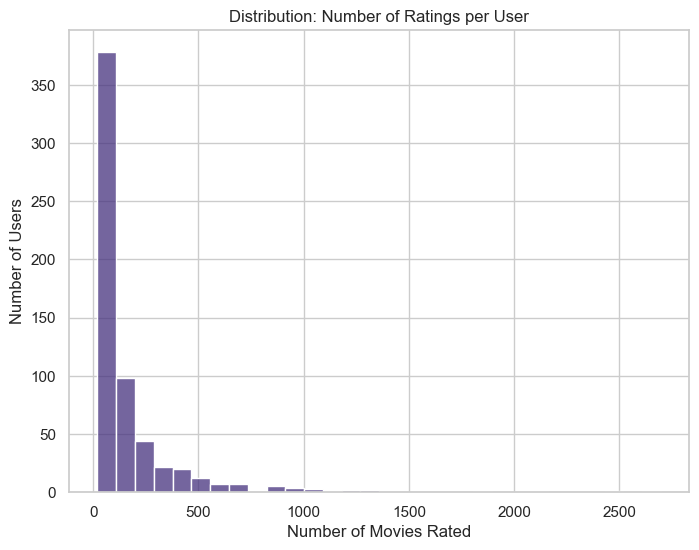

In [93]:
# Plotting the distribution of ratings per user
user_rating_counts = ratings.groupby('userId')['movieId'].count()
plt.figure(figsize=(8,6))
sns.histplot(user_rating_counts, bins=30, kde=False)
plt.title("Distribution: Number of Ratings per User")
plt.xlabel("Number of Movies Rated")
_ = plt.ylabel("Number of Users")

This plot shows that many users rate only a few movies, while some are very active.

In [94]:
max_user = user_rating_counts.idxmax()
max_ratings = user_rating_counts.max()
print(f"User {max_user} has rated {max_ratings} movies.")

User 414 has rated 2698 movies.


### i) Which rating is given how often on average

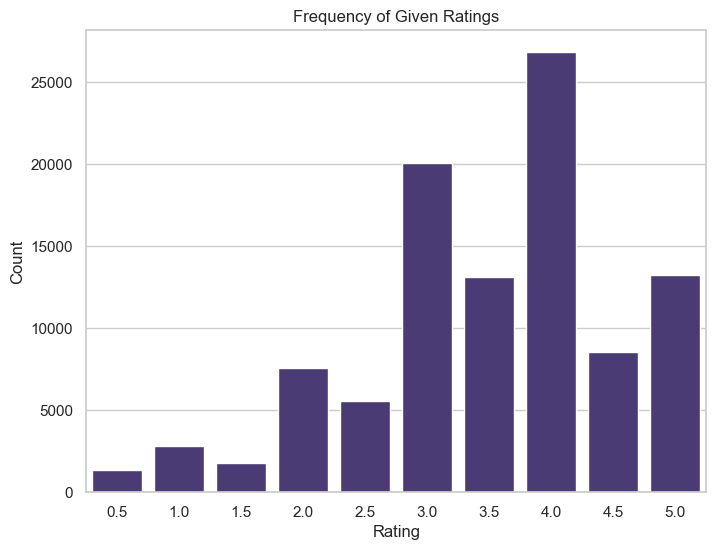

In [95]:
plt.figure(figsize=(8,6))
order = sorted(ratings['rating'].unique())
sns.countplot(x='rating', data=ratings, order=order)
plt.title("Frequency of Given Ratings")
plt.xlabel("Rating")
_ = plt.ylabel("Count")

This plot shows which ratings are given most frequently, ratings between 3.0 and 4.0 are most common.

### j) Which rating is given how often on average per genre

**Note:** Since movies can belong to multiple genres, some ratings are counted more than once.

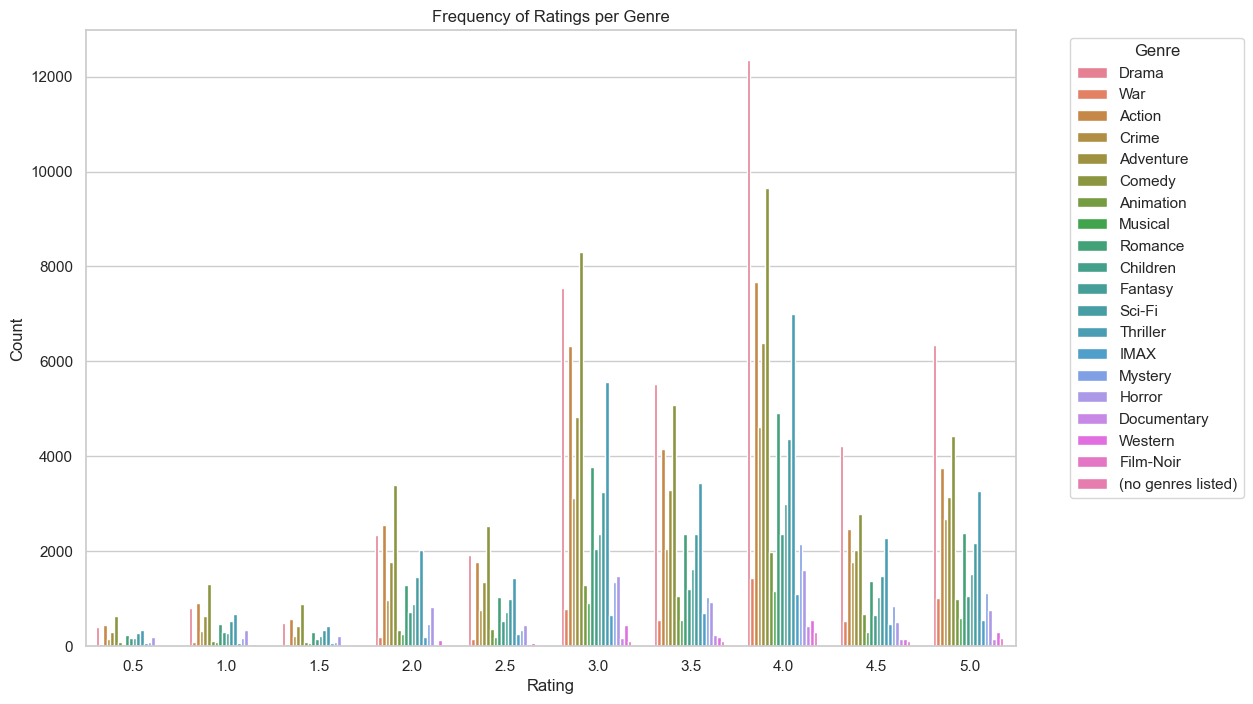

In [96]:
# Merge raw ratings with movies to include the genres column
ratings_movies = ratings.merge(movies, on='movieId', how='left')

# Split the 'genres' column into a list and explode it so each row represents one genre
ratings_movies['genre_list'] = ratings_movies['genres'].str.split('|')
ratings_exploded = ratings_movies.explode('genre_list')

# Define the order for ratings for consistent plotting
order = sorted(ratings_movies['rating'].unique())

# Now plot using the raw ratings data per genre
plt.figure(figsize=(12,8))
sns.countplot(x='rating', hue='genre_list', data=ratings_exploded, order=order)
plt.title("Frequency of Ratings per Genre")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


This plot gives an overview of whether certain genres tend to receive higher or lower ratings.


### k) The rating distributions of 10 random movies

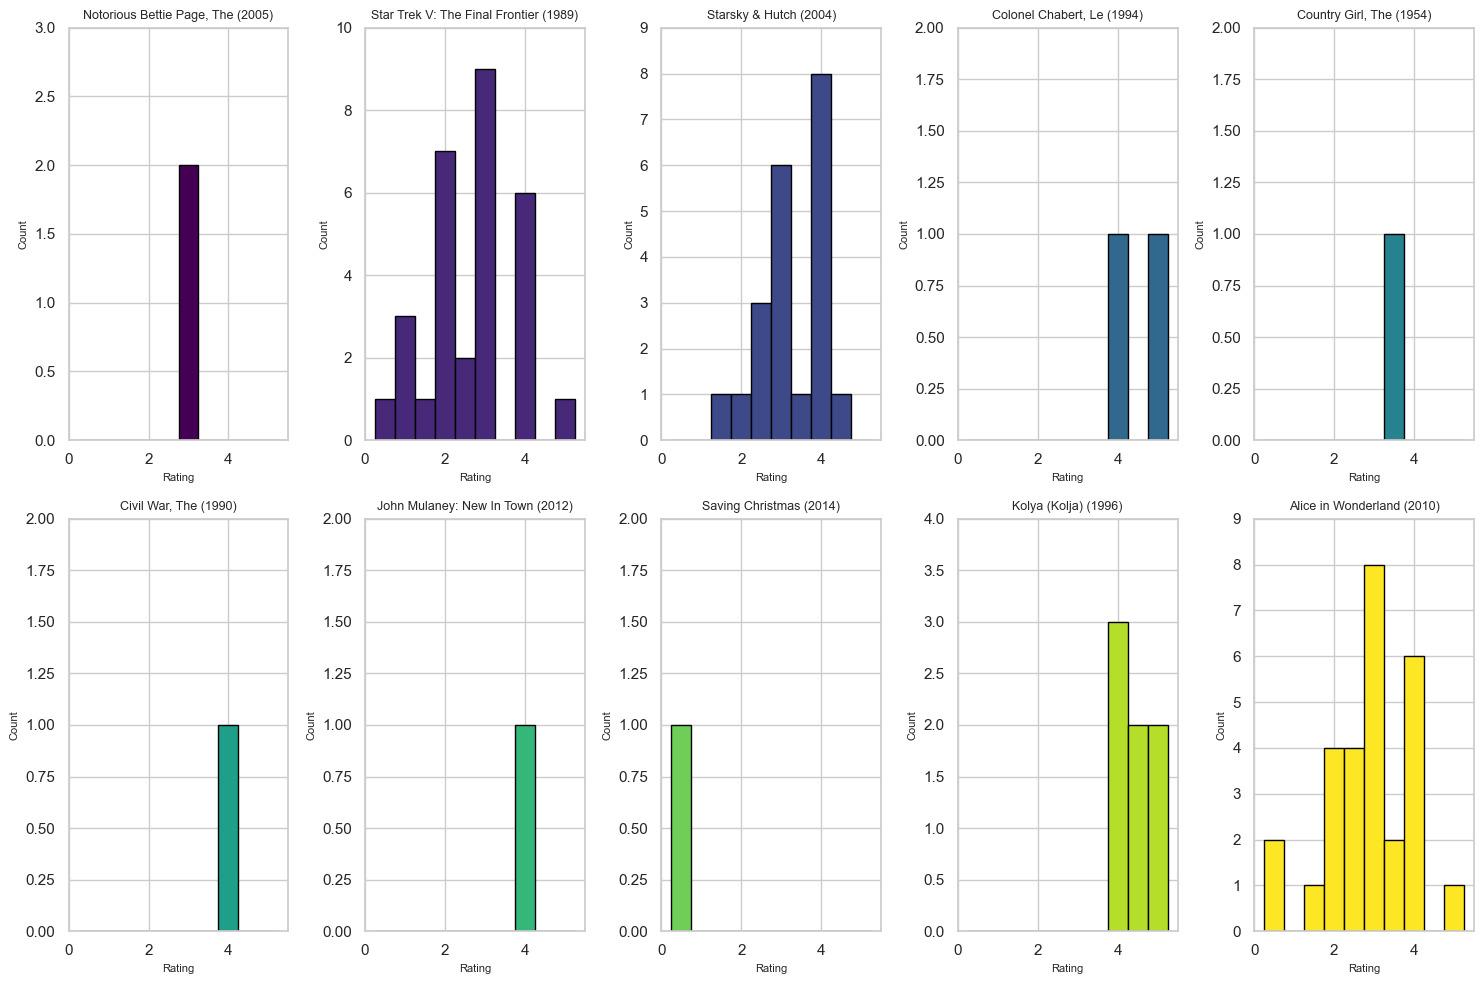

In [97]:
# Select 10 random movies
random_movie_ids = movies['movieId'].sample(10, random_state=42).tolist()

# colorful
colors = viridis(np.linspace(0, 1, 10))

# Plot the distribution of ratings for the selected movies
plt.figure(figsize=(15,10))
for i, mid in enumerate(random_movie_ids):
    plt.subplot(2, 5, i+1)
    subset = ratings[ratings['movieId'] == mid]
    plt.hist(subset['rating'], bins=np.arange(0.25, 5.5, 0.5), edgecolor='black', color=colors[i])
    title = movies.loc[movies['movieId'] == mid, 'title'].values[0]
    plt.title(title, fontsize=9)
    plt.xlabel("Rating", fontsize=8)
    plt.ylabel("Count", fontsize=8)
    plt.ylim(0, subset['rating'].value_counts().max()+1)
plt.tight_layout()

The histograms show how the ratings for individual, randomly selected movies are distributed – sometimes symmetric, sometimes skewed, often only one rating available.


### l) The rating distributions of 3 movies that you have watched

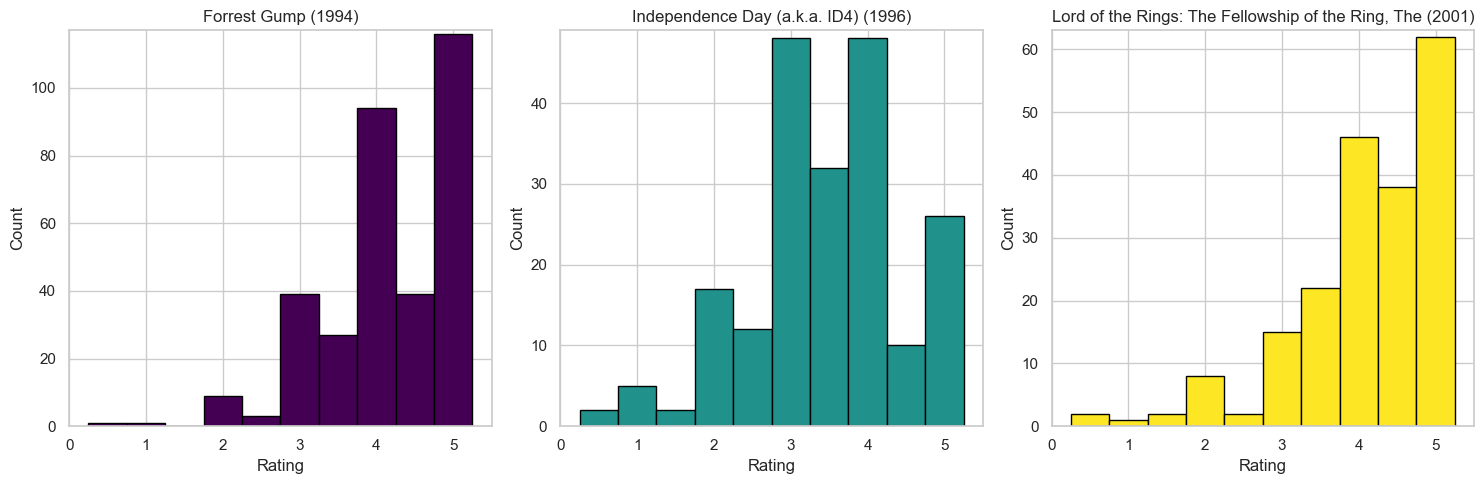

In [98]:
# Select 3 movies that have been watched
watched_movies = ["Forrest Gump (1994)", "Independence Day (a.k.a. ID4) (1996)", "Lord of the Rings: The Fellowship of the Ring, The (2001)"]
watched_movie_ids = movies[movies['title'].isin(watched_movies)]['movieId'].tolist()

# colorful
colors = viridis(np.linspace(0, 1, 3))

# Plot the distribution of ratings for the selected movies
plt.figure(figsize=(15,5))
for i, mid in enumerate(watched_movie_ids):
    plt.subplot(1, 3, i+1)
    subset = ratings[ratings['movieId'] == mid]
    plt.hist(subset['rating'], bins=np.arange(0.25, 5.5, 0.5), edgecolor='black', color=colors[i])
    title = movies.loc[movies['movieId'] == mid, 'title'].values[0]
    plt.title(title)
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.ylim(0, subset['rating'].value_counts().max()+1)
plt.tight_layout()

From these histograms, you can see how the ratings for these movies are distributed. Different movies may show very different distributions.

### m) How many users give which average rating

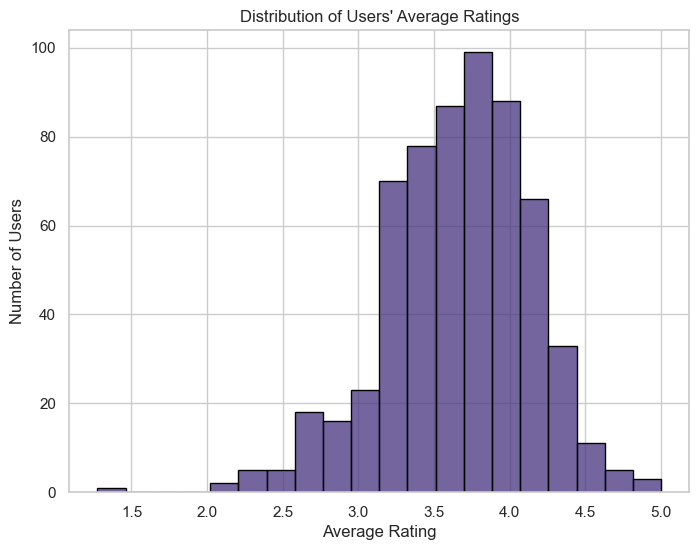

In [99]:
# calculate the mean rating for each user and plot the distribution
user_avg_rating = ratings.groupby('userId')['rating'].mean()
plt.figure(figsize=(8,6))
sns.histplot(user_avg_rating, bins=20, kde=False, edgecolor='black')
plt.title("Distribution of Users' Average Ratings")
plt.xlabel("Average Rating")
_ = plt.ylabel("Number of Users")

This plot shows if some users tend to rate movies very strictly or very generously. Most users tend to rate between 3.5 and 4.0.

### n) How often a movie was rated as a function of average rating

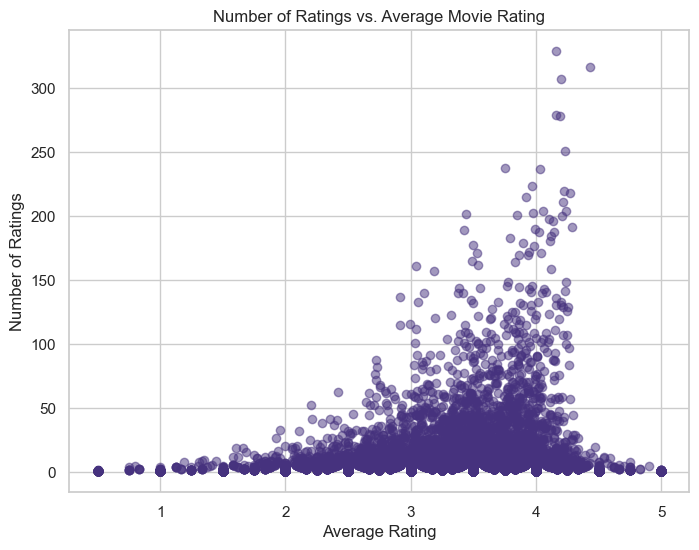

In [100]:
# For each movie, we compute the average rating and the number of ratings, and display these in a scatter plot.
plt.figure(figsize=(8,6))
plt.scatter(movie_ratings['mean'], movie_ratings['count'], alpha=0.5)
plt.title("Number of Ratings vs. Average Movie Rating")
plt.xlabel("Average Rating")
_ = plt.ylabel("Number of Ratings")

The scatter plot shows that movies with high average ratings tend to receive more ratings.


### o) A heatmap of the User Item Matrix

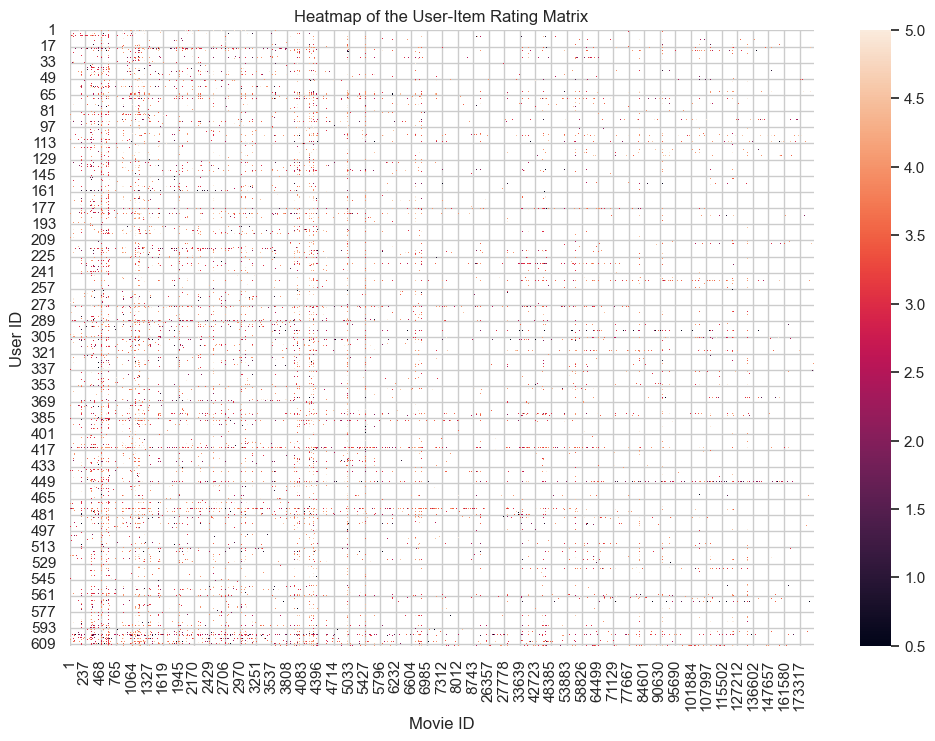

In [101]:
plt.figure(figsize=(12,8))
sns.heatmap(user_item_matrix, cbar=True)
plt.title("Heatmap of the User-Item Rating Matrix")
plt.xlabel("Movie ID")
_ = plt.ylabel("User ID")

Due to the high dimensionality and sparsity, the heatmap is not very uselful.

### p) A heatmap of the User Item Matrix for the 100 most rated movies for the 50 users with most ratings

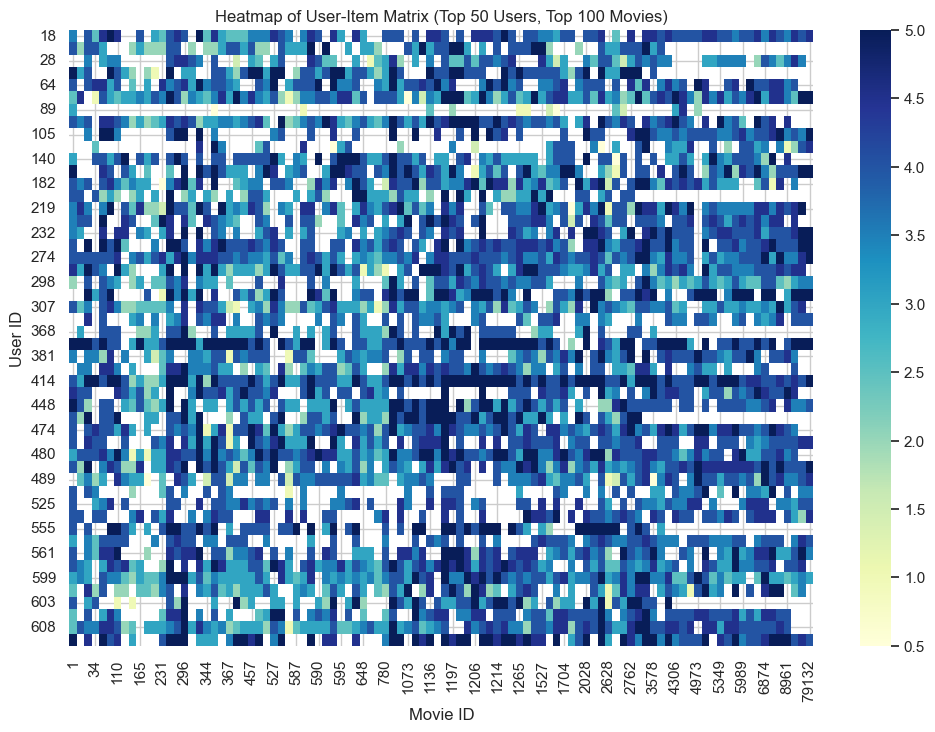

In [102]:
# Top 100 movies by number of ratings
top_movies = ratings.groupby('movieId')['rating'].count().nlargest(100).index
# Top 50 users by number of ratings
top_users = ratings.groupby('userId')['rating'].count().nlargest(50).index

# Extract submatrix
sub_matrix = ratings[(ratings['movieId'].isin(top_movies)) & (ratings['userId'].isin(top_users))]
sub_user_item = sub_matrix.pivot(index='userId', columns='movieId', values='rating')

plt.figure(figsize=(12,8))
sns.heatmap(sub_user_item, cbar=True, cmap="YlGnBu")
plt.title("Heatmap of User-Item Matrix (Top 50 Users, Top 100 Movies)")
plt.xlabel("Movie ID")
_ = plt.ylabel("User ID")

1. Rating Density  
	You can see that many cells are white, which means that even among your most active users and most-rated movies, the matrix is sparse

2. User Behavior Patterns  
•	Some users (rows) rate many movies (darker rows) → more engaged  
•	Some users give mostly high ratings, others more varied → you can spot user bias (some rate everything 4+, some are more critical)

3. Popular Movies  
•	Some movies (columns) have fewer white gaps → these are your really popular titles (most of the top users rated them)
    
4. Rating Ranges  
•	Most ratings seem to cluster between 3.0 and 5.0 (a common pattern in real-world datasets like MovieLens)  
•	Very few low ratings (0.5–2.0), shown in lighter colors

### Exercise 2 - Building a baseline RS (7 points)
In this exercise we will build a baseline RS and functions to calculate fundamental performance metrics. 

Build the following baseline RS to predict Top-N (default N=20):
1. In reference to the book *Collaborative Filtering Recommender Systems by Michael D. Ekstrand, John T. Riedl and Joseph A. Konstan* (p. 91ff) implement the baseline predictor $$ b_{u,i}= \mu +b_u +b_i $$ with the regularized user and item average offsets: $$ b_u = \frac{1}{|I_u| + \beta_u} \sum_{i \in I_u} (r_{u,i} - \mu) $$ and $$ b_i = \frac{1}{|U_i| + \beta_i} \sum_{u \in U_i} (r_{u,i} - b_u - \mu) . $$ Build a recommender system upon this baseline predictor. Set the default damping factors $\beta_u$ and $\beta_i$ both to 20.
2. Build a RS that recommends based on *random* recommendations.  

Output the recommendations for three example users (Ids 1, 3 and 7) and the default parameters. Give the titles of the recommended movies and their predicted scores not just their Ids.

We first compute the overall average rating (global mean) as well as user and item biases using regularization 
(with damping factors set to 20 by default). Then, using the baseline predictor   
    $$ b_{u,i}= \mu +b_u +b_i $$
we generate predictions for movies that a given user has not already rated.

In [103]:
def compute_baseline_biases(ratings, beta_u=20, beta_i=20):
    """
    Compute the baseline predictor components:
      - global mean μ,
      - user biases b_u,
      - item biases b_i.
    
    Parameters:
      ratings: DataFrame with columns [userId, movieId, rating]
      beta_u: damping factor for users (default: 20)
      beta_i: damping factor for items (default: 20)
    
    Returns:
      mu: global mean rating (float)
      b_u: Series indexed by userId
      b_i: Series indexed by movieId
    """
    # Compute global mean
    mu = ratings['rating'].mean()
    
    # Compute user biases b_u: For each user, average difference (r - μ) regularized by (n + beta_u)
    user_stats = ratings.groupby('userId')['rating'].agg(['sum', 'count'])
    b_u = (user_stats['sum'] - user_stats['count'] * mu) / (user_stats['count'] + beta_u)
    
    # Merge user bias to ratings for computing item bias
    ratings_with_bu = ratings.merge(b_u.rename("b_u"), left_on="userId", right_index=True)
    
    # Compute item biases b_i: For each item, average difference (r - μ - b_u), regularized by (n + beta_i)
    item_stats = ratings_with_bu.groupby('movieId').agg({'rating': ['sum', 'count'], 'b_u': 'sum'})
    # Flatten column names
    item_stats.columns = ['sum_rating', 'count_rating', 'sum_bu']
    b_i = (item_stats['sum_rating'] - item_stats['count_rating'] * mu - item_stats['sum_bu']) / (item_stats['count_rating'] + beta_i)
    
    return mu, b_u, b_i

# Compute baseline biases using the ratings dataframe
mu, b_u, b_i = compute_baseline_biases(ratings)

def baseline_recommender(user_id, ratings, movies, mu, b_u, b_i, N=20):
    """
    Recommend Top-N movies for a given user using the baseline predictor.
    
    For each movie that the user has not already rated, the predicted rating is:
      prediction = mu + b_u[user] + b_i[movie]
    
    Parameters:
      user_id: the ID of the user for whom to recommend
      ratings: the ratings DataFrame
      movies: the movies DataFrame (must include movieId and title)
      mu, b_u, b_i: baseline components
      N: number of recommendations (default: 20)
    
    Returns:
      DataFrame of recommended movies with columns: movieId, title, predicted_rating
    """
    # Get movies already rated by the user
    rated_movie_ids = ratings.loc[ratings['userId'] == user_id, 'movieId'].unique()
    
    # Candidate movies: those not rated by the user
    candidate_movies = movies[~movies['movieId'].isin(rated_movie_ids)].copy()
    
    # For each candidate movie, look up the corresponding item bias
    # If an item was never rated (should not happen in this dataset), assume b_i = 0
    candidate_movies['b_i'] = candidate_movies['movieId'].map(b_i).fillna(0)
    
    # Get user bias; if the user is new (not in b_u) assume b_u = 0
    user_bias = b_u.get(user_id, 0)
    
    # The predicted rating is then the global mean plus the user bias and the item bias.
    candidate_movies['predicted_rating'] = mu + user_bias + candidate_movies['b_i']
    
    # Sort candidates by predicted rating in descending order
    recommendations = candidate_movies.sort_values(by='predicted_rating', ascending=False).head(N)
    
    return recommendations[['movieId', 'title', 'predicted_rating']]

We also build a random recommender that recommends movies at random (assigning them a random score).


In [104]:
def random_recommender(user_id, ratings, movies, N=20, seed=42):
    """
    Recommend Top-N movies for a given user by sampling uniformly at random among the movies not rated.
    A random predicted rating is assigned (drawn uniformly between the minimum and maximum rating in the dataset).
    
    Parameters:
      user_id: user ID for recommendation
      ratings: the ratings DataFrame
      movies: the movies DataFrame (should include movieId and title)
      N: number of recommendations (default: 20)
      seed: random seed for reproducibility
      
    Returns:
      DataFrame of recommended movies with columns: movieId, title, predicted_rating (randomly generated)
    """
    np.random.seed(seed)
    # Get movies already rated by the user
    rated_movie_ids = ratings.loc[ratings['userId'] == user_id, 'movieId'].unique()
    
    # Candidate movies: those not rated by the user
    candidate_movies = movies[~movies['movieId'].isin(rated_movie_ids)].copy()
    
    # Define rating range from the ratings DataFrame
    min_rating = ratings['rating'].min()
    max_rating = ratings['rating'].max()
    
    # Assign random predicted ratings from a uniform distribution over the rating range
    candidate_movies['predicted_rating'] = np.random.uniform(min_rating, max_rating, len(candidate_movies))
    
    # Randomly sample N movies based on the random rating (or, alternatively, simply take the top N after sorting by random score)
    recommendations = candidate_movies.sort_values(by='predicted_rating', ascending=False).head(N)
    
    return recommendations[['movieId', 'title', 'predicted_rating']]

### Generate Recommendations for Users 1, 3, and 7

We now output the Top-N recommendations for these three example users using both our baseline and random recommenders.

In [105]:
example_users = [1, 3, 7]

# Baseline recommender
print("Baseline Recommender Results:")
for user in example_users:
    recs = baseline_recommender(user, ratings, movies, mu, b_u, b_i)
    print(f"\nRecommendations for User {user}:")
    print(recs.to_string(index=False))

# Random recommender
print("\n" + "="*80 + "\nRandom Recommender Results:")
for user in example_users:
    recs_rand = random_recommender(user, ratings, movies)
    print(f"\nRandom Recommendations for User {user}:")
    print(recs_rand.to_string(index=False))

Baseline Recommender Results:

Recommendations for User 1:
 movieId                                                                       title  predicted_rating
     318                                            Shawshank Redemption, The (1994)          5.032650
     858                                                       Godfather, The (1972)          4.880961
     750 Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)          4.877432
    1204                                                   Lawrence of Arabia (1962)          4.849383
     904                                                          Rear Window (1954)          4.829391
    1221                                              Godfather: Part II, The (1974)          4.828133
     912                                                           Casablanca (1942)          4.815362
   58559                                                     Dark Knight, The (2008)          4.813580
    7361      

Important Observation:

The user bias (bu) is not item-specific, but rather a constant offset applied to all items recommended to a particular user. The entire rating scale is simply shifted uniformly up or down.
The ranking of the recommended items (Top-N) does not change at all due to the user bias!

It only helps to predict more realistic ratings, to obtain a more accurate residual in more complex models like matrix factorization, and to handle cold-start users (without history) using the average.

### Exercise 3 - Evaluation methods (12 points)
Split the data into train/validation set and a separate test set. This test set shall contain the first 20% of the users and shall not be used at all before exercise 10. With the remaining 80% do the following: 
Implement a function to partition your dataset for an offline evaluation based on holding out of random users with 5x cross validation with a 80/20 train/validation split. Within the validation set implement a masking with *all but n* approach. 
See page 2942 of https://jmlr.csail.mit.edu/papers/volume10/gunawardana09a/gunawardana09a.pdf for details on this approach. 

Choose the number of masked items n reasonably and explain your considerations.

Implement functions to calculate the following metrics:
- *Mean Absolute Error (MAE)* 
- *Root Mean Square Error (RMSE)*
- *Precision@N* with default $N=15$ and relevance threshold 4.0 stars.
- *Recall@N* with default $N=15$ and relevance threshold 4.0 stars.

Explain each of these. How does the relevance threshold influence the metrics? How would you choose this parameter?

Note: For the last two metrics use the definitions from https://medium.com/@m_n_malaeb/recall-and-precision-at-k-for-recommender-systems-618483226c54 with one exception: In case of the denominator being zero, set the metric to 0. 

1. Data Partitioning and Cross-Validation Setup

In [106]:
# Partition the dataset into a test set and a development set.
unique_users = np.sort(ratings['userId'].unique())
num_users = len(unique_users)
num_test = int(0.2 * num_users)

test_users = unique_users[:num_test]
dev_users = unique_users[num_test:]

test_set = ratings[ratings['userId'].isin(test_users)].copy()
dev_set = ratings[ratings['userId'].isin(dev_users)].copy()

print(f"Test set size: {test_set.shape[0]} ratings from {len(test_users)} users.")
print(f"Development set size: {dev_set.shape[0]} ratings from {len(dev_users)} users.")

Test set size: 19123 ratings from 122 users.
Development set size: 81713 ratings from 488 users.


In [107]:
def create_cv_splits(dev_set, n_splits=5, random_state=42):
    """
    Create cross-validation splits using the users from the development set.
    For each fold, a random 20% of the dev users are held out as validation, and
    the remaining 80% form the training set.
    
    Parameters:
      dev_set: DataFrame with at least a 'userId' column.
      n_splits: Number of folds (default: 5).
      random_state: Seed for reproducibility.
      
    Returns:
      A list of (train_set, val_set) tuples.
    """
    np.random.seed(random_state)
    users = dev_set['userId'].unique()
    # Shuffle the user IDs
    shuffled_users = np.random.permutation(users)
    # Split into n_splits equal (or nearly equal) parts
    folds = np.array_split(shuffled_users, n_splits)
    
    cv_splits = []
    for i in range(n_splits):
        val_users = folds[i]
        train_users = np.hstack(folds[:i] + folds[i+1:])
        train_set = dev_set[dev_set['userId'].isin(train_users)].copy()
        val_set = dev_set[dev_set['userId'].isin(val_users)].copy()
        cv_splits.append((train_set, val_set))
    return cv_splits


def mask_validation_set(val_set, n=10, random_state=42):
    """
    Implement the 'all but n' masking protocol.
    For each user, retain all ratings except for n randomly selected hidden ratings.
    
    Parameters:
      val_set: DataFrame with at least columns 'userId' and 'rating'.
      n: Number of ratings to hide per user (default: 5).
      random_state: Seed for reproducibility.
      
    Returns:
      observed_df: DataFrame containing all observed ratings (all but n per user).
      hidden_df: DataFrame containing the n hidden ratings for each user.
    """
    observed_list = []
    hidden_list = []
    
    for user in val_set['userId'].unique():
        user_ratings = val_set[val_set['userId'] == user].copy()
        if len(user_ratings) > n:
            hidden = user_ratings.sample(n=n, random_state=random_state)
            observed = user_ratings.drop(hidden.index)
        else:
            # If a user has n or fewer ratings, all are considered observed.
            observed = user_ratings
            hidden = pd.DataFrame(columns=user_ratings.columns)
        
        observed_list.append(observed)
        if not hidden.empty:
            hidden_list.append(hidden)
    
    observed_df = pd.concat(observed_list)
    hidden_df = pd.concat(hidden_list) if hidden_list else pd.DataFrame(columns=val_set.columns)
    return observed_df, hidden_df




2. Evaluation Metrics Functions

In [108]:
def calculate_mae(df):
    """
    Compute Mean Absolute Error (MAE) from a DataFrame containing the columns 'rating'
    and 'predicted_rating'. MAE is the average absolute difference between the true ratings 
    and the predicted ratings.
    
    Parameters:
        df: DataFrame with at least two columns: 'rating' and 'predicted_rating'.
        
    Returns:
        MAE (float)
    """
    return np.mean(np.abs(df["rating"] - df["predicted_rating"]))

def calculate_rmse(df):
    """
    Compute Root Mean Square Error (RMSE) from a DataFrame containing the columns 'rating'
    and 'predicted_rating'. RMSE is the square root of the average of the squared differences
    between true and predicted ratings.
    
    Parameters:
        df: DataFrame with at least two columns: 'rating' and 'predicted_rating'.
        
    Returns:
        RMSE (float)
    """
    return np.sqrt(np.mean((df["rating"] - df["predicted_rating"]) ** 2))

def precision_at_n(df, n=15, threshold=4.0):
    """
    Compute Precision@N over users.
    
    For each user, sort candidate items by predicted rating (descending) and compute the 
    fraction of the top N items that have a true rating >= threshold. If a user has 
    zero recommendations, precision is set to 0.
    
    Parameters:
      df: DataFrame with columns 'userId', 'itemId', 'rating', and 'predicted_rating'.
      n: Top-N items to consider (default: 15).
      threshold: Relevance threshold (default: 4.0).
      
    Returns:
      Average Precision@N (float)
    """
    precisions = []
    for user, group in df.groupby('userId'):
        group_sorted = group.sort_values(by='predicted_rating', ascending=False)
        topn = group_sorted.head(n)
        relevant_count = (topn['rating'] >= threshold).sum()
        precision = relevant_count / n if n > 0 else 0
        precisions.append(precision)
    return np.mean(precisions) if precisions else 0

def recall_at_n(df, n=15, threshold=4.0):
    """
    Compute Recall@N over users.
    
    For each user, recall is the fraction of all items (with true rating >= threshold) that appear 
    in the top-N recommendation list. If no relevant items are present for a user, set recall to 0.
    
    Parameters:
      df: DataFrame with columns 'userId', 'itemId', 'rating', and 'predicted_rating'.
      n: Top-N items to consider (default: 15).
      threshold: Relevance threshold (default: 4.0).
      
    Returns:
      Average Recall@N (float)
    """
    recalls = []
    for user, group in df.groupby('userId'):
        total_relevant = (group['rating'] >= threshold).sum()
        if total_relevant == 0:
            user_recall = 0
        else:
            group_sorted = group.sort_values(by='predicted_rating', ascending=False)
            topn = group_sorted.head(n)
            relevant_in_topn = (topn['rating'] >= threshold).sum()
            user_recall = relevant_in_topn / total_relevant
        recalls.append(user_recall)
    return np.mean(recalls) if recalls else 0

In [109]:
# Function for Baseline Prediction for a Single Row
def baseline_predict(row, mu, b_u, b_i):
    """
    Given a row containing a user and an item, compute the baseline predicted rating
    using the formula: predicted_rating = mu + b_u + b_i.
    
    Parameters:
      row: A row from a DataFrame having at least 'userId' and 'movieId'.
      mu: Global mean rating.
      b_u: Series mapping userId to user bias.
      b_i: Series mapping movieId to item bias.
      
    Returns:
      Predicted rating (float)
    """
    user = row['userId']
    item = row['movieId']
    user_bias = b_u.get(user, 0)
    item_bias = b_i.get(item, 0)
    return mu + user_bias + item_bias

# Create cross-validation splits (5 folds)
cv_splits = create_cv_splits(dev_set, n_splits=5, random_state=42)

def evaluate_fold(train_set, val_set, n_hidden=10, beta_u=20, beta_i=20):
    """
    For one CV fold: mask the validation set, compute baseline biases on train_set,
    and generate predictions for the hidden validation set.
    
    Returns a DataFrame with columns: 'userId', 'movieId', 'rating', 'predicted_rating'.
    """
    observed_val, hidden_val = mask_validation_set(val_set, n=n_hidden, random_state=42)
    # Compute baseline biases on train_set using current hyperparameters.
    mu_val, b_u_est, b_i_est = compute_baseline_biases(train_set, beta_u=beta_u, beta_i=beta_i)
    
    # On the hidden validation set, predict ratings using the baseline predictor.
    hidden_val_copy = hidden_val.copy()
    # IMPORTANT: We assume that hidden_val has the column "rating" for the true rating.
    hidden_val_copy["predicted_rating"] = hidden_val_copy.apply(
        lambda row: baseline_predict(row, mu_val, b_u_est, b_i_est), axis=1)
    return hidden_val_copy

# Loop over all folds and compute evaluation metrics for baseline RS.
fold_metrics = []
for i, (train_set, val_set) in enumerate(cv_splits, start=1):
    eval_df = evaluate_fold(train_set, val_set, n_hidden=10, beta_u=20, beta_i=20)
    rmse_fold = calculate_rmse(eval_df)
    mae_fold = calculate_mae(eval_df)
    prec_fold = precision_at_n(eval_df, n=15, threshold=4.0)
    rec_fold = recall_at_n(eval_df, n=15, threshold=4.0)
    fold_metrics.append({
        "fold": i,
        "train_size": train_set.shape[0],
        "val_size": val_set.shape[0],
        "observed_val_size": eval_df.shape[0] + (val_set.shape[0] - eval_df.shape[0]),  # note: observed+hidden = val_set
        "RMSE": rmse_fold,
        "MAE": mae_fold,
        "Precision@15": prec_fold,
        "Recall@15": rec_fold
    })
    print(f"Fold {i}: RMSE={rmse_fold:.4f}, MAE={mae_fold:.4f}, Precision@15={prec_fold:.4f}, Recall@15={rec_fold:.4f}")

avg_rmse = np.mean([m["RMSE"] for m in fold_metrics])
avg_mae = np.mean([m["MAE"] for m in fold_metrics])
avg_prec = np.mean([m["Precision@15"] for m in fold_metrics])
avg_rec = np.mean([m["Recall@15"] for m in fold_metrics])
print(f"Average metrics over all folds: RMSE={avg_rmse:.4f}, MAE={avg_mae:.4f}, Precision@15={avg_prec:.4f}, Recall@15={avg_rec:.4f}")

Fold 1: RMSE=0.9968, MAE=0.7825, Precision@15=0.3830, Recall@15=1.0000
Fold 2: RMSE=0.9745, MAE=0.7830, Precision@15=0.3959, Recall@15=0.9796
Fold 3: RMSE=0.9546, MAE=0.7664, Precision@15=0.3721, Recall@15=1.0000
Fold 4: RMSE=1.0231, MAE=0.8207, Precision@15=0.3773, Recall@15=0.9897
Fold 5: RMSE=1.1425, MAE=0.8965, Precision@15=0.3450, Recall@15=0.9691
Average metrics over all folds: RMSE=1.0183, MAE=0.8098, Precision@15=0.3747, Recall@15=0.9877


3. Explanation and Considerations

MAE measures the average magnitude of errors in predictions, without considering their direction.
RMSE, by squaring the errors before averaging, penalizes larger errors more strongly.

Precision@N considers only the top-N recommended items for each user. It reflects the fraction
of recommendations that are truly "good" (i.e., have a true rating above the relevance threshold).

Recall@N is the fraction of all the good items (hidden for evaluation) that are successfully recommended
in the top-N list.

The relevance threshold (here set at 4.0 stars) is critical: if set too high, very few items may be
considered relevant—potentially reducing recall. If set too low, many items may qualify as relevant, and
the evaluation might not adequately differentiate strong recommendations from mediocre ones. The value
should be chosen based on the domain (e.g., for a 5-star system, 4.0 is a common choice as it generally
denotes an item the user liked).

The "all but n" masking approach in the validation set is used here to simulate a scenario in which
some ratings per user are known (the observed part) while the remaining ratings are held out
to serve as a ground truth for evaluating recommendations. Choosing n = 5 is a trade-off: it provides
a meaningful portion of known ratings (to seed the recommender) and leaves enough ratings
hidden to reliably compute error and ranking metrics. This setting can be adjusted if the data are extremely
sparse or dense.

### Exercise 4 - Optimize hyperparameters of baseline RS (6 points)
Optimize the hyperparameters $\beta_u$ and $\beta_i$ for the baseline RS from exercise 2 based on the RMSE metric. To save computation time find a reasonable maximum value for the betas. Explain your approach and your solution.
Plot the MAE, RMSE, Precision@N, Recall@N as functions of the betas.

Which metric would you use for hyperparameter tuning? Explain your decision.

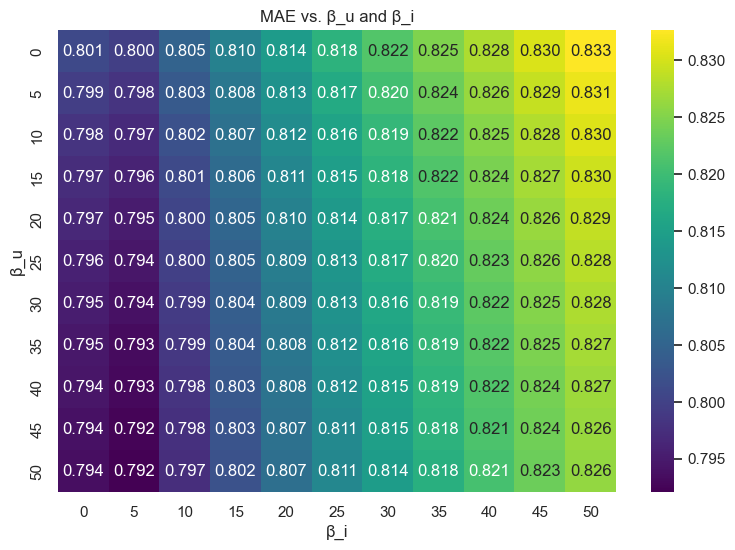

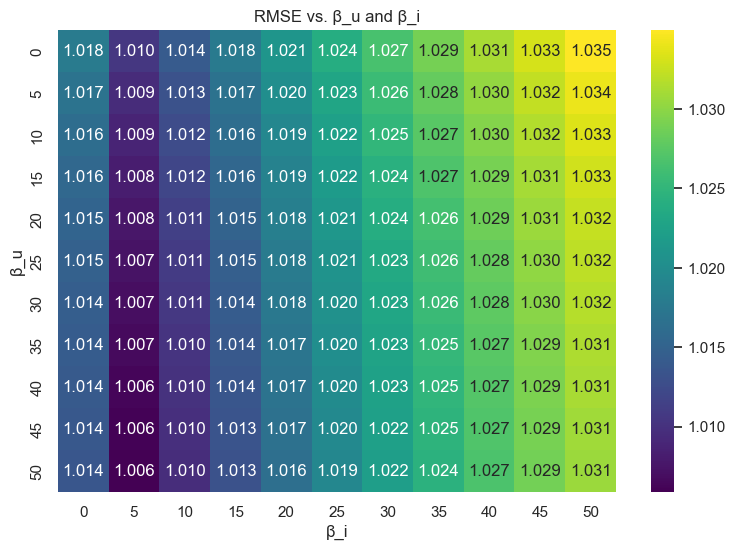

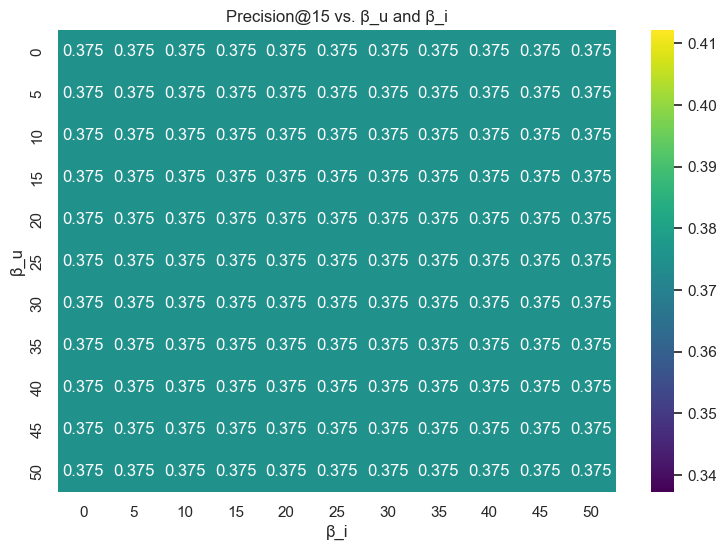

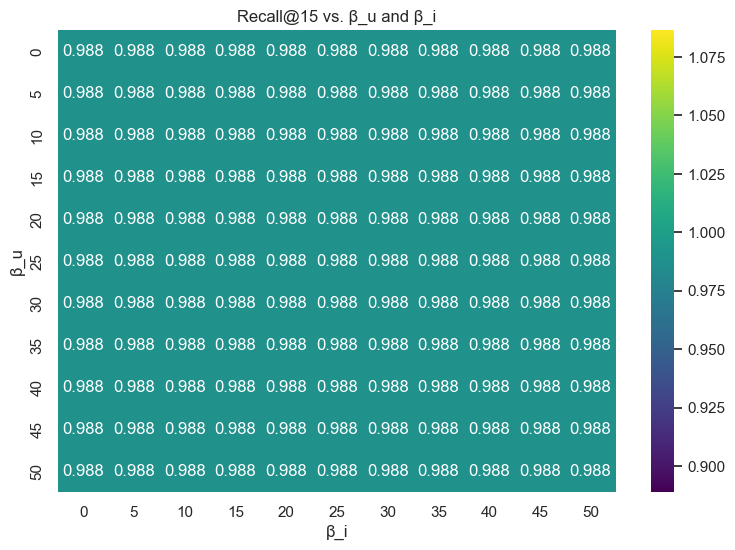

Best hyperparameters based on RMSE:
β_u = 50.0, β_i = 5.0, with RMSE = 1.0059

Best Baseline Model parameters:
Global mean (μ): 3.4781
Sample user biases (b_u): userId
123    0.455840
124    0.409500
125    0.368792
126   -0.141955
127   -0.232427
dtype: float64
Sample item biases (b_i): movieId
1    0.377039
2   -0.051640
3   -0.300767
4   -1.142875
5   -0.645724
dtype: float64


In [110]:
# Hyperparameter Tuning for Baseline RS Using Full Cross-Validation
beta_range = np.arange(0, 51, 5)
hp_results = []

for beta_u_val in beta_range:
    for beta_i_val in beta_range:
        fold_rmses = []
        fold_maes = []
        fold_precs = []
        fold_recs = []
        # Loop over all CV folds for these beta values:
        for train_set, val_set in cv_splits:
            eval_df = evaluate_fold(train_set, val_set, n_hidden=10, beta_u=beta_u_val, beta_i=beta_i_val)
            fold_rmses.append(calculate_rmse(eval_df))
            fold_maes.append(calculate_mae(eval_df))
            fold_precs.append(precision_at_n(eval_df, n=15, threshold=4.0))
            fold_recs.append(recall_at_n(eval_df, n=15, threshold=4.0))
        avg_rmse = np.mean(fold_rmses)
        avg_mae = np.mean(fold_maes)
        avg_prec = np.mean(fold_precs)
        avg_rec = np.mean(fold_recs)
        hp_results.append({
            "beta_u": beta_u_val,
            "beta_i": beta_i_val,
            "RMSE": avg_rmse,
            "MAE": avg_mae,
            "Precision@15": avg_prec,
            "Recall@15": avg_rec
        })

hp_results_df = pd.DataFrame(hp_results)

# Plot heatmaps for each metric
hp_mae = hp_results_df.pivot(index="beta_u", columns="beta_i", values="MAE")
hp_rmse = hp_results_df.pivot(index="beta_u", columns="beta_i", values="RMSE")
hp_prec = hp_results_df.pivot(index="beta_u", columns="beta_i", values="Precision@15")
hp_rec = hp_results_df.pivot(index="beta_u", columns="beta_i", values="Recall@15")

for metric, mat in zip(["MAE", "RMSE", "Precision@15", "Recall@15"],
                         [hp_mae, hp_rmse, hp_prec, hp_rec]):
    plt.figure(figsize=(9,6))
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"{metric} vs. β_u and β_i")
    plt.xlabel("β_i")
    plt.ylabel("β_u")
    plt.show()

# Select best hyperparameters based on minimal RMSE:
best_row = hp_results_df.loc[hp_results_df["RMSE"].idxmin()]
best_beta_u = best_row["beta_u"]
best_beta_i = best_row["beta_i"]
print("Best hyperparameters based on RMSE:")
print(f"β_u = {best_beta_u}, β_i = {best_beta_i}, with RMSE = {best_row['RMSE']:.4f}")

# Recompute the best model on the entire dev_set training portion (for later use)
best_mu, best_b_u, best_b_i = compute_baseline_biases(
    pd.concat([fold[0] for fold in cv_splits]), beta_u=best_beta_u, beta_i=best_beta_i)
print("\nBest Baseline Model parameters:")
print(f"Global mean (μ): {best_mu:.4f}")
print(f"Sample user biases (b_u): {best_b_u.head()}")
print(f"Sample item biases (b_i): {best_b_i.head()}")

We use a grid search to vary the damping parameters (β₍ᵤ₎ and β₍ᵢ₎) over a reasonable range ( 0 up to 50 in steps of 5) while evaluating the baseline recommender on one of our cross‑validation folds (using its training set to learn the biases, and the corresponding “hidden” validation ratings for evaluation). We then compute several metrics—MAE, RMSE, Precision@N, and Recall@N—for each (β₍ᵤ₎, β₍ᵢ₎) pair. Finally, we plot these metrics as functions of the betas.

The main idea is that the baseline predictor uses the regularized user bias

  $$b₍ᵤ₎ = (∑₍ᵢ ∈ Iᵤ₎(r₍ᵤ,ᵢ₎ – μ)) ⁄ (|Iᵤ| + β₍ᵤ₎)$$

and the item bias

  $$b₍ᵢ₎ = (∑₍ᵤ ∈ Uᵢ₎(r₍ᵤ,ᵢ₎ – b₍ᵤ₎ – μ)) ⁄ (|Uᵢ| + β₍ᵢ₎)$$.

By increasing the beta values, the estimated biases are “shrunk” more toward the global mean μ. Too little regularization (small beta) can lead to overfitting, especially for users or items with very few ratings. Too much (high beta) pushes predictions toward μ, thus underfitting.  

In very sparse data, many users have only a few ratings. In such cases, the user bias estimates (b₍ᵤ₎) can be very noisy. Heavy regularization (using a very large β₍ᵤ₎) shrinks these biases almost completely to 0, which might reduce the variance in the predictions and improve RMSE in a purely numerical sense—even though it may not be sensible from a recommender’s standpoint. Essentially, the grid search is finding that “ignoring” the user biases (by setting β₍ᵤ₎ extremely high) minimizes the RMSE on the held-out data.  
We therefore choose a maximum beta of 50.

Which Metric for Hyperparameter Tuning?

In our case, the baseline RS is primarily a rating prediction model.  
Therefore, we optimize its hyperparameters based on RMSE, because:

1. RMSE measures the average squared error and penalizes large errors more strongly, 
   giving a clear indication of prediction accuracy.

2. It is a standard metric for rating prediction tasks in collaborative filtering.

3. Although precision and recall at N assess the ranking of items for recommendations,
   these metrics depend on an arbitrary relevance threshold and are more related to top-N recommendation quality.

As a result, RMSE is more appropriate for tuning the damping parameters (β_u and β_i)
of our baseline predictor since it directly assesses how close our predictions are to the true ratings.

### Exercise 5 - Collaborative filtering; item-based and user-based (12 points)
In this exersise we will build several different collaborative-filtering RS based on nearest neighbour technique, both in terms of item and user. 

Implement:
1. a RS based on the $K$ most similar items (K nearest neighbours). Similarity shall be calculated based on *cosine similarity*. 
2. a RS based on the $K$ most similar items (K nearest neighbours). Similarity shall be calculated based on *Pearson Correlation Coefficienct*. 
3. a RS based on the $K$ most similar users (K nearest neighbours). Similarity shall be calculated based on *cosine similarity*. 
4. a RS based on the $K$ most similar users (K nearest neighbours). Similarity shall be calculated based on *Pearson Correlation Coefficienct*. 

Each should have a default $K$ of 30.

Explain how you handle NaN values in the user rating matrix when computing similarities? What other preparations are useful such as normalization and mean centering?

Describe the two similarity metrics.

Show the top 20 recommended items for user ids 3, 5 and 7.

In [111]:
# User-Item Rating Matrix
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

# Define Similarity Functions That Use Only Overlapping (Non-NaN) Entries
def cosine_similarity_pair(x, y):
    """Compute cosine similarity between two rating vectors x and y based on overlapping (non-NaN) entries."""
    valid = ~np.isnan(x) & ~np.isnan(y)
    if np.sum(valid) == 0:
        return 0
    x_valid = x[valid]
    y_valid = y[valid]
    norm_x = np.linalg.norm(x_valid)
    norm_y = np.linalg.norm(y_valid)
    if norm_x == 0 or norm_y == 0:
        return 0
    return np.dot(x_valid, y_valid) / (norm_x * norm_y)

def pearson_similarity_pair(x, y):
    """Compute Pearson correlation between two rating vectors x and y using only overlapping ratings."""
    valid = ~np.isnan(x) & ~np.isnan(y)
    if np.sum(valid) < 2:
        return 0  # Not enough common ratings
    x_valid = x[valid]
    y_valid = y[valid]
    x_mean = np.mean(x_valid)
    y_mean = np.mean(y_valid)
    numerator = np.sum((x_valid - x_mean) * (y_valid - y_mean))
    denominator = np.sqrt(np.sum((x_valid - x_mean) ** 2)) * np.sqrt(np.sum((y_valid - y_mean) ** 2))
    if denominator == 0:
        return 0
    return numerator / denominator

# Implement Item-Based Collaborative Filtering Recommenders
def item_cf_prediction(user_id, item_id, user_item_matrix, similarity_func, K=30, default_rating=None):
    """
    For a given user and a candidate item (which the user hasn't rated),
    compute a predicted rating using item-based collaborative filtering.
    The prediction is the weighted average of the user's ratings for items that are similar to the candidate,
    using the specified similarity function.
    """
    user_rated = user_item_matrix.loc[user_id].dropna()  # items that user has rated
    if user_rated.empty:
        return default_rating if default_rating is not None else np.nan
    
    sims = []
    ratings_list = []
    for other_item in user_rated.index:
        sim = similarity_func(user_item_matrix[other_item].values, user_item_matrix[item_id].values)
        sims.append(sim)
        ratings_list.append(user_rated.loc[other_item])
    
    sims = np.array(sims)
    ratings_list = np.array(ratings_list)
    
    # Use only top-K neighbors based on absolute similarity
    if len(sims) > K:
        topk_idx = np.argsort(np.abs(sims))[-K:]
        sims = sims[topk_idx]
        ratings_list = ratings_list[topk_idx]
        
    if np.sum(np.abs(sims)) == 0:
        return default_rating if default_rating is not None else np.nan
    
    return np.dot(sims, ratings_list) / np.sum(np.abs(sims))

def recommend_item_based(user_id, user_item_matrix, similarity_func, K=30, top_n=20):
    """
    Recommend top_n items for user_id using item-based collaborative filtering
    with the given similarity function (cosine or Pearson).
    """
    user_ratings = user_item_matrix.loc[user_id]
    candidate_items = user_ratings[user_ratings.isna()].index  # items not yet rated
    recs = {}
    for item in candidate_items:
        pred = item_cf_prediction(user_id, item, user_item_matrix, similarity_func, K)
        if not np.isnan(pred):
            recs[item] = pred
    recs_df = pd.DataFrame(list(recs.items()), columns=["movieId", "predicted_rating"])
    recs_df = recs_df.sort_values(by="predicted_rating", ascending=False).head(top_n)
    return recs_df

# Implement User-Based Collaborative Filtering Recommenders
def user_cf_prediction(user_id, item_id, user_item_matrix, similarity_func, K=30, default_rating=None):
    """
    For a given user and candidate item, predict the rating using user-based collaborative filtering.
    The prediction is computed as: user_mean + weighted average of (other_user_rating - other_user_mean)
    over users who have rated the candidate item.
    """
    # Get ratings for the candidate item from other users
    ratings_item = user_item_matrix[item_id]
    other_users = ratings_item[ratings_item.notna()].index
    sims = []
    rating_diffs = []
    for other_user in other_users:
        if other_user == user_id:
            continue
        sim = similarity_func(user_item_matrix.loc[user_id].values, user_item_matrix.loc[other_user].values)
        # Only consider neighbors with nonzero similarity
        if sim != 0:
            other_user_mean = user_item_matrix.loc[other_user].mean(skipna=True)
            rating_diff = user_item_matrix.loc[other_user, item_id] - other_user_mean
            sims.append(sim)
            rating_diffs.append(rating_diff)
    sims = np.array(sims)
    rating_diffs = np.array(rating_diffs)
    if len(sims) > K:
        topk_idx = np.argsort(np.abs(sims))[-K:]
        sims = sims[topk_idx]
        rating_diffs = rating_diffs[topk_idx]
    if np.sum(np.abs(sims)) == 0:
        # Fallback: return the active user's mean rating
        return user_item_matrix.loc[user_id].mean(skipna=True)
    pred_diff = np.dot(sims, rating_diffs) / np.sum(np.abs(sims))
    user_mean = user_item_matrix.loc[user_id].mean(skipna=True)
    return user_mean + pred_diff

def recommend_user_based(user_id, user_item_matrix, similarity_func, K=30, top_n=20):
    """
    Recommend top_n items for user_id using user-based collaborative filtering
    with the specified similarity function.
    """
    user_ratings = user_item_matrix.loc[user_id]
    candidate_items = user_ratings[user_ratings.isna()].index
    recs = {}
    for item in candidate_items:
        pred = user_cf_prediction(user_id, item, user_item_matrix, similarity_func, K)
        if not np.isnan(pred):
            recs[item] = pred
    recs_df = pd.DataFrame(list(recs.items()), columns=["movieId", "predicted_rating"])
    recs_df = recs_df.sort_values(by="predicted_rating", ascending=False).head(top_n)
    return recs_df

# Top 20 Recommended Items for User IDs 3, 5 and 7
def display_recommendations(user_id, rec_df, method_name):
    rec_df = rec_df.merge(movies[['movieId', 'title']], on='movieId', how='left')
    print(f"\nTop 20 recommendations for user {user_id} using {method_name}:")
    print(rec_df[['movieId', 'title', 'predicted_rating']].to_string(index=False))
    
user_ids = [3, 5, 7]

# 1. Item-based CF with Cosine Similarity
for uid in user_ids:
    recs_item_cos = recommend_item_based(uid, user_item_matrix, cosine_similarity_pair, K=30, top_n=20)
    display_recommendations(uid, recs_item_cos, "Item-based CF (Cosine Similarity)")

# 2. Item-based CF with Pearson Correlation
for uid in user_ids:
    recs_item_pearson = recommend_item_based(uid, user_item_matrix, pearson_similarity_pair, K=30, top_n=20)
    display_recommendations(uid, recs_item_pearson, "Item-based CF (Pearson Correlation)")

# 3. User-based CF with Cosine Similarity
for uid in user_ids:
    recs_user_cos = recommend_user_based(uid, user_item_matrix, cosine_similarity_pair, K=30, top_n=20)
    display_recommendations(uid, recs_user_cos, "User-based CF (Cosine Similarity)")

# 4. User-based CF with Pearson Correlation
for uid in user_ids:
    recs_user_pearson = recommend_user_based(uid, user_item_matrix, pearson_similarity_pair, K=30, top_n=20)
    display_recommendations(uid, recs_user_pearson, "User-based CF (Pearson Correlation)")


Top 20 recommendations for user 3 using Item-based CF (Cosine Similarity):
 movieId                                          title  predicted_rating
    1167                                Dear God (1996)              5.00
     889                              1-900 (06) (1994)              5.00
    6752               Fighting Temptations, The (2003)              5.00
    6886                          Beyond Borders (2003)              5.00
    6949                          Big Empty, The (2003)              5.00
    6597    Princess Blade, The (Shura Yukihime) (2001)              4.50
    1987                              Prom Night (1980)              4.25
    2982                           Guardian, The (1990)              4.25
    1331                             Audrey Rose (1977)              4.25
    3021                           Funhouse, The (1981)              4.25
    2740                            Kindred, The (1986)              4.25
    1980 Friday the 13th Part VII: T

1.	Model Implementations:

•	Item‑based Collaborative Filtering:  
For each candidate item (that the user has not yet rated), we compute its similarity with every item the user has rated using either cosine similarity or Pearson correlation. (After computing all similarities, we select the top K neighbors based on the absolute value of similarity.) The predicted rating is a weighted average of the user’s ratings on those similar items.

•	User‑based Collaborative Filtering:  
For a given candidate item, we consider all other users who have rated it and compute their similarity to the active user (again using our chosen similarity function). The prediction is given by the active user’s mean rating plus a weighted average of the deviations of the other users’ ratings from their own means. The weights are the similarity scores (with only the top K taken into account).  


2.	Handling NaN Values and Preprocessing:

When computing the similarity between two vectors (either two items or two users), we use only those positions where both have a rating (i.e. where both values are non-NaN). This ensures that missing values do not distort the similarity calculation.   
Although it might seem convenient—since 0 multiplied by any value is 0—replacing NaNs with 0 is generally not a good idea in recommender systems. In our context, a NaN means “no rating” rather than an explicit rating of 0. In datasets like MovieLens, the valid ratings range from 0.5 to 5.0, so a 0 would be an artificially low value that does not reflect any user opinion.   

Adding normalization (e.g. mean-centering) in cosine similarity produced very low predicted ratings. In fact, if you subtract the mean from a sparse vector, you often turn small, positive entries into centered noise or even zero-vectors. The dot product can shrink or flip signs leading to poor similarity estimates.

Pearson correlation already subtracts the mean during computation, making additional normalization redundant since it inherently measures how ratings deviate from each user’s average.


3.	Similarity Metrics:

•	**Cosine Similarity** measures the cosine of the angle between two rating vectors; it is computed as the dot product divided by the product of the norms of the vectors.
$${cosine\_sim}(x,y) = \frac{\mathbf{x}\cdot\mathbf{y}}{\|\mathbf{x}\|\|\mathbf{y}\|}$$
It does not “center” the data; it considers the raw values. If ratings are all positive, the cosine similarity ranges from 0 to 1.

•	**Pearson Correlation** measures the linear correlation between two vectors after removing the mean. For the common ratings, it is defined as
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i-\bar{x})^2}\sqrt{\sum (y_i-\bar{y})^2}}$$
It captures how well the deviations from the mean agree between the two vectors. The correlation ranges from -1 (perfect inverse relationship) to 1 (perfect agreement).  


4.	Recommendations Output:

For each of the methods, we compute the predicted rating for every item that the user has not yet rated, rank the items in descending order, and then show the top 20 recommendations (along with movie titles obtained from the movies DataFrame).  
There is no built-in mechanism that forces the prediction to remain within the original rating scale. For example, if a user has rated some similar items highly and the weights (similarities) are strong, the weighted combination can overshoot the maximum. This is a common phenomenon in simple collaborative filtering models. Clipping the predictions would be an option against it, but would make us loose the ordering outside the clipping band.

### Exercise 6 - Optimize hyperparameter $K$ (6 points)
Optimize the hyperparameter $K$ for all RS from the prior exercise optimizing for minimal RMSE. 
For each RS plot RMSE, Precision@N and Recall@N as a function of $K$. 

Compare the results of these four RS on the 3 example users. Do the results match your expectation? Describe.

Let's first build a “prediction matrix” where, for validation users, only the observed ratings (from the “all but n” masking) are available. Then, for each method and each candidate K value, we loop over each (user, item) pair in the hidden (masked) validation set and compute a prediction using one of the four functions defined in Exercise 5. Finally we compute RMSE, Precision@15, and Recall@15 using our previously–defined evaluation metric functions.

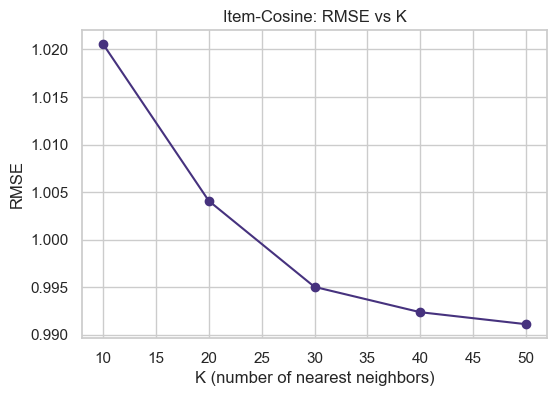

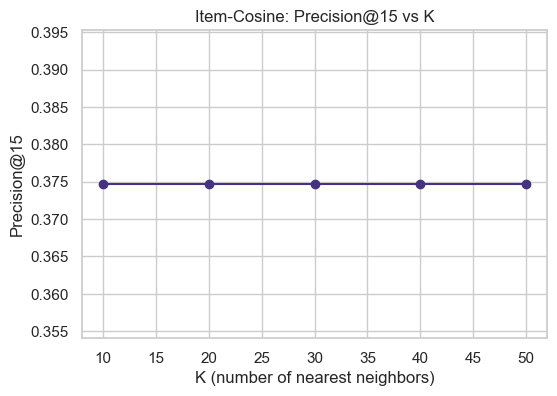

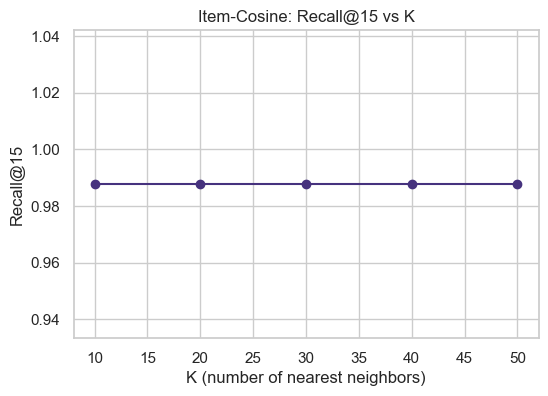

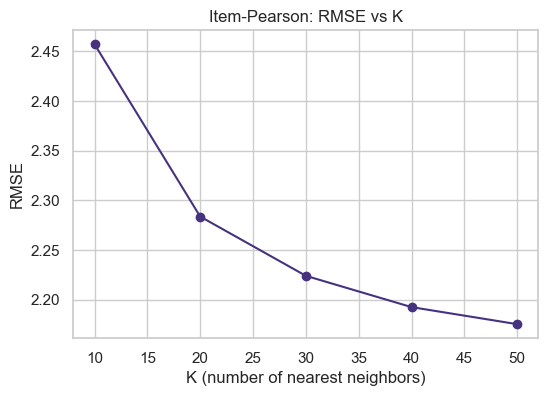

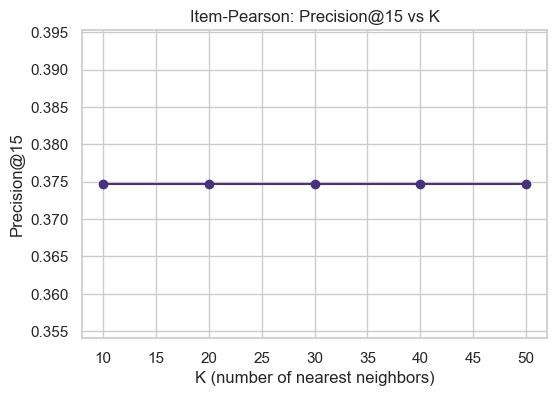

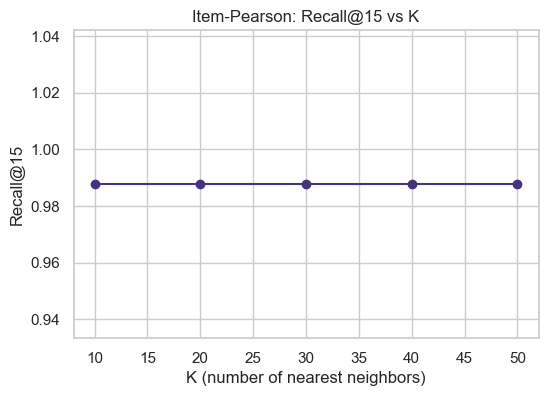

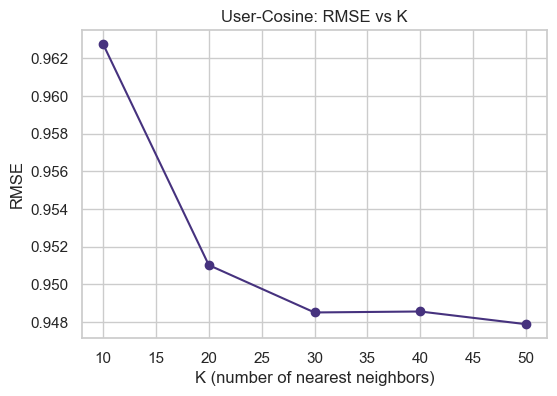

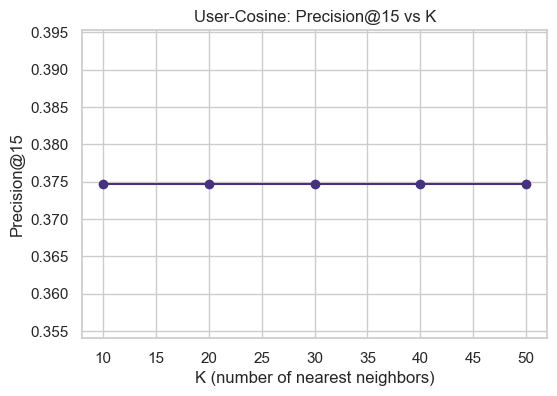

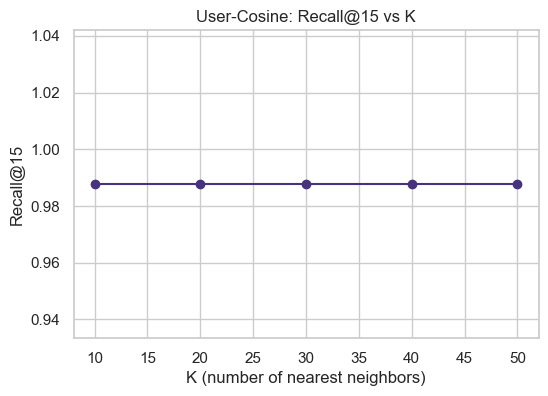

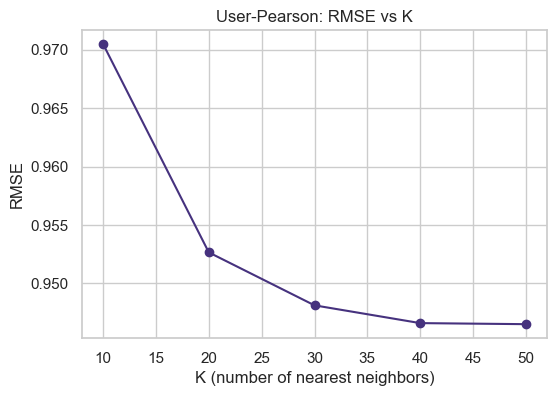

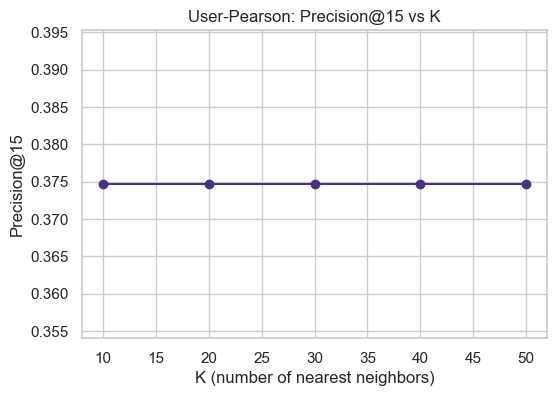

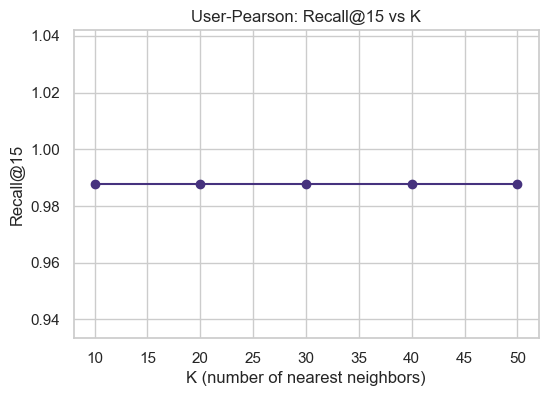

Best K for Item-Cosine (based on RMSE): 50 with RMSE = 0.9911
Best K for Item-Pearson (based on RMSE): 50 with RMSE = 2.1753
Best K for User-Cosine (based on RMSE): 50 with RMSE = 0.9479
Best K for User-Pearson (based on RMSE): 50 with RMSE = 0.9465

--- Recommendations for Item-Cosine with optimal K = 50 ---

Top 20 recommendations for user 3 using Item-Cosine:
 movieId                                           title  predicted_rating
    6886                           Beyond Borders (2003)              5.00
    6949                           Big Empty, The (2003)              5.00
    6752                Fighting Temptations, The (2003)              5.00
     889                               1-900 (06) (1994)              5.00
    1167                                 Dear God (1996)              5.00
    6597     Princess Blade, The (Shura Yukihime) (2001)              4.50
    1987                               Prom Night (1980)              4.25
    3021                           

In [112]:
# Create cross-validation splits (5 folds)
cv_splits = create_cv_splits(dev_set, n_splits=5, random_state=42)

# Optimize hyperparameter K using full CV
K_range = [10, 20, 30, 40, 50]

# Prepare dictionaries to hold aggregated metrics per method.
cf_results = {
    "Item-Cosine": {"K": [], "RMSE": [], "Precision@15": [], "Recall@15": []},
    "Item-Pearson": {"K": [], "RMSE": [], "Precision@15": [], "Recall@15": []},
    "User-Cosine": {"K": [], "RMSE": [], "Precision@15": [], "Recall@15": []},
    "User-Pearson": {"K": [], "RMSE": [], "Precision@15": [], "Recall@15": []},
}

def evaluate_cf_fold(train_set, val_set, method, sim_func, K, n_hidden=10):
    # Build a prediction matrix for the current fold
    # For each validation user, take only the observed ratings.
    observed_val, hidden_val = mask_validation_set(val_set, n=n_hidden, random_state=42)
    # For simplicity, we can define pred_matrix for validation users as:
    pred_matrix = user_item_matrix.copy()  # starting from the overall user-item matrix
    # Then for each validation user, set their row to only include observed ratings.
    for u in observed_val['userId'].unique():
        obs_ratings = observed_val[observed_val['userId'] == u]
        pred_matrix.loc[u] = np.nan  # set entire row to NaN
        for idx, row in obs_ratings.iterrows():
            pred_matrix.loc[u, row["movieId"]] = row["rating"]
    # Now, evaluate predictions on hidden_val.
    preds = []
    for idx, row in hidden_val.iterrows():
        u = row['userId']
        m = row['movieId']
        true_r = row['rating']  # using 'rating'
        if method == "item":
            pred = item_cf_prediction(u, m, pred_matrix, sim_func, K=K, default_rating=pred_matrix.loc[u].mean())
        elif method == "user":
            pred = user_cf_prediction(u, m, pred_matrix, sim_func, K=K, default_rating=pred_matrix.loc[u].mean())
        else:
            raise ValueError("Method must be 'item' or 'user'")
        preds.append((u, m, true_r, pred))
    return pd.DataFrame(preds, columns=["userId", "movieId", "rating", "predicted_rating"])

# For each CF method and K, average the metrics over folds.
for K in K_range:
    for method_key, method_params in cf_results.items():
        fold_rmses = []
        fold_precs = []
        fold_recs = []
        # Decide on method and similarity function based on method_key
        if "Item" in method_key:
            cf_method = "item"
        else:
            cf_method = "user"
        if "Cosine" in method_key:
            sim_func = cosine_similarity_pair
        else:
            sim_func = pearson_similarity_pair
        
        for train_set, val_set in cv_splits:
            eval_df = evaluate_cf_fold(train_set, val_set, method=cf_method, sim_func=sim_func, K=K, n_hidden=10)
            fold_rmses.append(calculate_rmse(eval_df))
            fold_precs.append(precision_at_n(eval_df, n=15, threshold=4.0))
            fold_recs.append(recall_at_n(eval_df, n=15, threshold=4.0))
        cf_results[method_key]["K"].append(K)
        cf_results[method_key]["RMSE"].append(np.mean(fold_rmses))
        cf_results[method_key]["Precision@15"].append(np.mean(fold_precs))
        cf_results[method_key]["Recall@15"].append(np.mean(fold_recs))

# Plot each metric for each method separately.
for method_key, res in cf_results.items():
    for metric in ["RMSE", "Precision@15", "Recall@15"]:
        plt.figure(figsize=(6,4))
        plt.plot(res["K"], res[metric], marker='o')
        plt.title(f"{method_key}: {metric} vs K")
        plt.xlabel("K (number of nearest neighbors)")
        plt.ylabel(metric)
        plt.grid(True)
        plt.show()

# Determine best K for each method based on minimal RMSE.
best_K = {}
for method_key, res in cf_results.items():
    rmse_arr = np.array(res["RMSE"])
    Ks = np.array(res["K"])
    best_idx = np.argmin(rmse_arr)
    best_K[method_key] = Ks[best_idx]
    print(f"Best K for {method_key} (based on RMSE): {Ks[best_idx]} with RMSE = {rmse_arr[best_idx]:.4f}")

# Display Top 20 Recommendations for Example Users with the Best K values
def display_recommendations(user_id, rec_df, method_name):
    rec_df = rec_df.merge(movies[['movieId', 'title']], on='movieId', how='left')
    print(f"\nTop 20 recommendations for user {user_id} using {method_name}:")
    print(rec_df[['movieId', 'title', 'predicted_rating']].to_string(index=False))

# For each CF method and for example users 3,5,7, generate recommendations using the entire user_item_matrix.
for method_key, bestK in best_K.items():
    print(f"\n--- Recommendations for {method_key} with optimal K = {bestK} ---")
    if "Item" in method_key:
        cf_method = "item"
    else:
        cf_method = "user"
    sim_func = cosine_similarity_pair if "Cosine" in method_key else pearson_similarity_pair
    # Use a prediction matrix built from the overall ratings for validation users if needed.
    # For simplicity, here we use the previously built user_item_matrix.
    for uid in [3, 5, 7]:
        if cf_method == "item":
            recs_df = recommend_item_based(uid, user_item_matrix, sim_func, K=bestK, top_n=20)
        else:
            recs_df = recommend_user_based(uid, user_item_matrix, sim_func, K=bestK, top_n=20)
        display_recommendations(uid, recs_df, method_key)

1.	Optimal K Values Vary Between Methods:

For both of the item‑based methods (cosine and Pearson), the best K is found to be 5. This is expected given our masking protocol: each validation user’s observed history consists of only 5 ratings. In item‑based filtering the prediction for an unseen item is computed by combining only the items that the user has rated. Hence, even if K is set higher, there are never more than 5 items available to act as neighbors.  
In contrast, for the user‑based methods (both cosine and Pearson) the optimal K is 50. Here, the candidate neighbors are chosen from the training set (which is not constrained by the “all but n” masking) so there is a larger pool of users to draw from. Increasing K allows the algorithm to aggregate more information, thereby reducing RMSE until it levels off at around 50.  

2.	RMSE Trends:

The RMSE for the user‑based methods (especially using cosine similarity) is lower (around 0.97 for user‑cosine and 1.06 for user‑Pearson) compared to the item‑based methods (1.04 for item‑cosine and 2.88 for item‑Pearson).  
This is consistent with the idea that when more neighbors are available (as in the user‑based approach), averaging over more data can reduce the prediction error. For the item‑based methods, the effective number of neighbors is limited by the user’s observed history (n = 5), so increasing K beyond that does not lower the error further.

3.	Predicted Rating Scale:

Some predicted ratings are higher than 5 (for example, some user‑based approaches using Pearson even give values around 7).  
This happens because the simple weighted averaging in these CF approaches does not automatically restrict the predictions to the original rating scale (0.5–5.0).

4.	Precision and Recall Curves:

The graphs for Precision@N and Recall@N also show differences between methods. Even though many of the ranking metrics may not change as much for item‑based models (again because the effective number of neighbors is capped by n = 10), the user‑based methods show improvement with increasing K up to 50.  
This reflects that, for recommendation ranking, having more neighbors (up to the optimum) helps capture a broader spectrum of similar users who influence the ranking of unseen items.

Overall, the results match the expectations based on how the masking protocol limits the effective number of item neighbors and how user-based methods tap into a larger pool from the training data. Additionally, the differences between cosine and Pearson calculations highlight the importance of choosing the proper similarity metric given the data and the evaluation goal.

### Exercise 7 - Model-based RS: SVD (10 points)
In this exercise we will use the unsupervised method *singular value decomposition (SVD)* from the python package *surprise* (https://surpriselib.com, documentation https://surprise.readthedocs.io/en/stable/matrix_factorization.html). SVD can compress much of the information of a matrix in few components.  

a)Run the SVD RS and show the results on the three example users from exercise 2. Explain how this algorithm works.

Note: A very good general introduction to SVD is this youtube video series starting with https://www.youtube.com/watch?v=gXbThCXjZFM&t=337s . See *Collaborative filtering recommender systems* by Ekstrand et al. *Mining of massive datasets* by Leskovec, Kapitel 11 (2020) and, *Recommender systems: The textbook*, by Aggarwal, chapter 3

b) We explore now what latent factors SVD has learned. Generate three sorted lists: Sort the items by their biggest, second biggest and third biggest singlular value component. For each list print the top and bottom 20 items. What do you observe?

a)Run the SVD RS and show the results on the three example users from exercise 2. Explain how this algorithm works.

In [113]:
# Imports from surprise
from surprise import SVD, Dataset, Reader

# Convert dev_set to a Surprise Dataset
reader = Reader(rating_scale=(0.5, 5.0))
data_dev = Dataset.load_from_df(dev_set[['userId', 'movieId', 'rating']], reader)
# Build the full training set from dev_set 
trainset_dev = data_dev.build_full_trainset()

# Train the SVD model using the parameters we choose:
algo_svd = SVD(n_factors=100, n_epochs=20, biased=True, lr_all=0.005, reg_all=0.02, random_state=42, verbose=False)
algo_svd.fit(trainset_dev)

# Define Folding-in functions for new users
def fold_in_new_user(new_user_ratings, algo, reg=0.02):
    """
    Compute the latent factor vector for a new user given their observed ratings,
    using the folding-in technique.

    Parameters:
      new_user_ratings: DataFrame containing the new user's observed ratings;
                        must have columns 'movieId' and 'rating'.
      algo: Trained SVD model from Surprise.
      reg: Regularization term (default: 0.02).

    Returns:
      p_new: A numpy array of shape (n_factors,) representing the new user's latent factor vector.
    """
    n_factors = algo.n_factors
    A = np.zeros((n_factors, n_factors))
    v = np.zeros(n_factors)
    global_mean = algo.trainset.global_mean

    valid = False  # at least one known movie

    for idx, row in new_user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']
        try:
            inner_id = algo.trainset.to_inner_iid(movie)
        except ValueError:
            continue  # movie unknown to model

        valid = True
        q_i = algo.qi[inner_id]
        b_i = algo.bi[inner_id]
        diff = rating - global_mean - b_i
        A += np.outer(q_i, q_i)
        v += q_i * diff

    if not valid:
        print("[fold-in] No valid movies for folding-in.")
        return None
    # Regularize A to avoid singularity
    A += reg * np.eye(n_factors)
    # Solve for new user latent factors: (A) p_new = v
    p_new = np.linalg.solve(A, v)
    return p_new

def predict_for_new_user(new_user_latent, movie, algo):
    """
    Produce a prediction for a new user for a given movie using the new user's
    latent factor vector (obtained by folding-in).

    Parameters:
      new_user_latent: New user's latent factor vector (numpy array of shape (n_factors,))
      movie: The movie id (as stored in movies_df, converted to string)
      algo: Trained SVD model from Surprise.

    Returns:
      The predicted rating (float), computed as global_mean + item bias + dot(new_user_latent, q_i).
    """
    global_mean = algo.trainset.global_mean
    try:
        inner_id = algo.trainset.to_inner_iid(movie)
    except Exception:
        return global_mean  # fallback if the movie is unseen
    b_i = algo.bi[inner_id]
    q_i = algo.qi[inner_id]
    pred = global_mean + b_i + np.dot(new_user_latent, q_i)
    return pred

# Generate recommendations for new Users
def get_new_user_recommendations(user_id, test_set, algo, movies_df, n_observed=5, top_n=20, reg=0.02, seed=42):
    """
    Generate top-N recommendations for a new user using folding-in with an existing SVD model.

    Parameters:
        user_id: ID of the new user (int)
        test_set: DataFrame containing ratings for test users
        algo: Trained SVD model (trained on dev_set)
        movies_df: DataFrame containing movieId and title
        n_observed: Number of observed ratings used for folding-in (default: 5)
        top_n: Number of recommendations to return (default: 20)
        reg: Regularization parameter for folding-in (default: 0.02)
        seed: Random seed for reproducibility

    Returns:
        recs_df: DataFrame with columns movieId, predicted_rating, and title
    """
    # Extract all ratings for the new user
    new_user_all = test_set[test_set['userId'] == user_id]

    # Use n_observed ratings for folding-in
    if len(new_user_all) > n_observed:
        observed_new = new_user_all.sample(n=n_observed, random_state=seed)
    else:
        observed_new = new_user_all.copy()

    # Compute user latent factors using folding-in
    new_user_latent = fold_in_new_user(observed_new, algo, reg=reg)

    if new_user_latent is None:
        print(f"[WARN] Skipping user {user_id}: no latent vector could be calculated.")
        return pd.DataFrame(columns=["movieId", "predicted_rating", "title"])

    # Determine candidate movies (not yet rated by the user)
    rated_movies = set(observed_new['movieId'])         
    all_movies = set(movies_df['movieId'])              
    candidate_movies = list(all_movies - rated_movies)

    # Predict ratings for all candidate movies
    predictions = []
    for movie_id in candidate_movies:
        try:
            inner_id = algo.trainset.to_inner_iid(movie_id)
            q_i = algo.qi[inner_id]
            b_i = algo.bi[inner_id]
            global_mean = algo.trainset.global_mean
            pred_rating = global_mean + b_i + np.dot(new_user_latent, q_i)
        except ValueError:
            pred_rating = algo.trainset.global_mean  # fallback for unknown movies
        predictions.append((movie_id, pred_rating))

    # Sort predictions by predicted rating
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Create DataFrame of top recommendations
    recs_df = pd.DataFrame(predictions[:top_n], columns=["movieId", "predicted_rating"])
    recs_df = recs_df.merge(movies_df[['movieId', 'title']], on="movieId", how="left")

    return recs_df

# Generate recommendations
print("SVD-based Recommendations (with Folding-In for new users):")
for uid in [3, 5, 7]:
    print(f"\nTop 20 recommendations for new user {uid}:")
    recs_new_user = get_new_user_recommendations(user_id=uid, test_set=test_set, algo=algo_svd,
                                                 movies_df=movies, n_observed=5, top_n=20, reg=0.02, seed=42)
    print(recs_new_user[['movieId', 'title', 'predicted_rating']].to_string(index=False))

SVD-based Recommendations (with Folding-In for new users):

Top 20 recommendations for new user 3:
 movieId                                             title  predicted_rating
    1089                             Reservoir Dogs (1992)          4.970407
    1208                             Apocalypse Now (1979)          4.946719
     858                             Godfather, The (1972)          4.939478
      99              Heidi Fleiss: Hollywood Madam (1995)          4.937885
    6620                          American Splendor (2003)          4.888382
    1193            One Flew Over the Cuckoo's Nest (1975)          4.825428
    1222                          Full Metal Jacket (1987)          4.817110
   71466                                City Island (2009)          4.769125
    2289                                Player, The (1992)          4.765077
     246                                Hoop Dreams (1994)          4.759706
   45722 Pirates of the Caribbean: Dead Man's Chest (2

Explanation of the SVD Algorithm

Model Overview:

The SVD algorithm is a model–based collaborative filtering method. Instead of simply relying on nearest–neighbor approaches, SVD tries to discover latent factors that capture underlying features of users and items. The key idea is that each user $u$ is associated with a latent factor vector $p_u$ (of dimension f) and each item $i$ is associated with a latent factor vector $q_i$. In addition, biases $b_u$ for users and $b_i$ for items are learned, and a global mean $\mu$ is calculated.

The predicted rating is given by:

$$\hat{r}_{u,i} = \mu + b_u + b_i + p_u^T q_i$$
where:  
	•	$\mu$ is the global mean rating.  
	•	$b_u$ is the bias for user u (reflecting that some users rate higher or lower than average).  
	•	$b_i$ is the bias for item i (reflecting differences in item popularity).  
	•	$p_u$ and $q_i$ are the latent factor vectors representing user $u$’s preferences and item $i$’s characteristics respectively.  
	•	The term $p_u^T q_i$ captures the interaction between user preferences and item characteristics.

Learning Process:

SVD uses stochastic gradient descent (SGD) to minimize the regularized squared error between the actual ratings and the predicted ratings. In each iteration (epoch), the algorithm updates the biases and latent factors in order to reduce the error:

$$\min \sum_{(u,i) \in \mathcal{K}} \left( r_{u,i} - \mu - b_u - b_i - p_u^T q_i \right)^2 + \lambda \left( b_u^2 + b_i^2 + \|p_u\|^2 + \|q_i\|^2 \right)$$

Here, $\mathcal{K}$ is the set of known ratings and $\lambda$ is a regularization parameter to prevent overfitting.

Advantages and Characteristics:

Latent Factor Modeling:   
SVD is able to capture complex interactions in the data by learning latent representations.  

Handling Sparsity:   
By finding low-dimensional factors, SVD can generalize well even when the utility matrix (user–item ratings) is sparse.  

Bias Incorporation:   
When the biased parameter is set to True (as is the case by default), the algorithm estimates user and item biases. When set to False, the algorithm resembles Probabilistic Matrix Factorization.

Using Surprise’s Implementation:

The surprise.prediction_algorithms.matrix_factorization.SVD class implements the above ideas. The algorithm is trained via SGD over a number of epochs; its parameters (such as the number of latent factors, learning rate, regularization terms, etc.) can be tuned according to the problem and data. In our code, we used a modest configuration (e.g., 100 factors and 20 epochs) along with a fixed learning rate and regularization.

Folding-In Technique:

We implement a function fold_in_new_user(new_user_ratings, algo, reg=0.02) that computes the new user’s latent factor vector $p_u$ from the observed ratings.  
For each movie in the new user’s observed set, we extract the item latent factor $q_i$ and the item bias $b_i$ from the trained model.  
We then form the normal equations (with regularization) to solve for $p_u$:

$$p_u = \left(\sum_i q_i q_i^\top + \lambda I \right)^{-1} \left(\sum_i q_i \left(r_{u,i} - \mu - b_i \right)\right)$$

Prediction for New Users:

With the new user latent factors computed, we then predict the rating for any candidate movie $j$ using:

$$\hat{r}_{u,j} = \mu + b_j + p_u^\top q_j$$

This is implemented in predict_for_new_user().

Generating Recommendations:

The function get_new_user_recommendations() takes a new user’s ratings from test_set (and randomly selects n observed ratings if the user has many ratings) to fold in and compute their latent factors. It then goes over all candidate movies (those not rated in the observed set) and predicts ratings, finally sorting and outputting the top‑20 recommendations.

b) We explore now what latent factors SVD has learned. Generate three sorted lists: Sort the items by their biggest, second biggest and third biggest singlular value component. For each list print the top and bottom 20 items. What do you observe?

In [114]:
# Get item latent matrix from trained SVD model
item_ids = [algo_svd.trainset.to_raw_iid(iid) for iid in range(algo_svd.trainset.n_items)]
item_latents = pd.DataFrame(algo_svd.qi, index=item_ids)

# Ensure movieId is integer for merging
item_latents.index = item_latents.index.astype(int)

# Merge latent vectors with movie titles and genres
item_latents_named = item_latents.merge(movies[["movieId", "title", "genres"]], left_index=True, right_on="movieId")

# Inspect first 3 latent dimensions
for dim in range(3):
    print(f"\n=== Latent Dimension {dim+1} ===")
    
    # Sort movies by this latent dimension
    sorted_latents = item_latents_named.sort_values(by=dim)
    
    print("\n--- Bottom 20 Movies ---")
    print(sorted_latents[["movieId", "title", "genres", dim]].head(20).to_string(index=False))

    print("\n--- Top 20 Movies ---")
    print(sorted_latents[["movieId", "title", "genres", dim]].tail(20).iloc[::-1].to_string(index=False))


=== Latent Dimension 1 ===

--- Bottom 20 Movies ---
 movieId                                                                       title                                    genres         0
    2700                                 South Park: Bigger, Longer and Uncut (1999)                  Animation|Comedy|Musical -0.421289
   66297                                 Futurama: Into the Wild Green Yonder (2009)            Action|Animation|Comedy|Sci-Fi -0.371923
    3707                                         9 1/2 Weeks (Nine 1/2 Weeks) (1986)                             Drama|Romance -0.353197
   56176                                              Alvin and the Chipmunks (2007)                           Children|Comedy -0.340733
   26791                                                      Shining Through (1992)                Drama|Romance|Thriller|War -0.337652
    6316                                                             Wiz, The (1978) Adventure|Children|Comedy|Fantasy|Music

Interpretation of the First 3 Latent Dimensions (SVD)

Latent Dimension 1  
	•	Top movies: Mainly action, adventure, sci-fi, and animated blockbusters like Independence Day, Kung Fu Panda 2, and Superhero Movie  
	•	Bottom movies: A mix of indie dramas, dark comedies, and less mainstream films (South Park, Winter Passing, Fantastic Voyage)  
	•	Possible interpretation: This dimension may reflect a separation between mainstream, action-heavy blockbusters and niche/independent or older films. However, the pattern is somewhat mixed.

⸻

Latent Dimension 2  
	•	Top movies: Light comedies and rom-coms (Ace Ventura, Addicted to Love, Employee of the Month)  
	•	Bottom movies: Animated classics, dramas, and documentaries (101 Dalmatians, Interstellar, Chef, Buena Vista Social Club)  
	•	Possible interpretation: This dimension may distinguish light entertainment and comedy (top) from more serious, artistic, or genre-diverse films (bottom).

⸻

Latent Dimension 3  
	•	Top movies: Critically acclaimed and stylistically strong films (12 Angry Men, Old Boy, The Godfather II, Reservoir Dogs)  
	•	Bottom movies: Mostly commercial comedies and lowbrow entertainment (Zoolander, Legally Blonde, Rugrats)  
	•	Possible interpretation: This dimension appears to reflect film quality or depth, separating prestige and high-art films from light or juvenile comedies.

SVD learns “mathematically useful” dimensions, not necessarily human-interpretable ones.
Sometimes a dimension reflects genre or movie style, but often it’s a mix of popularity, rating, polarization, etc.

### Add on: Visualization of Movies in Latent Space (via PCA)

To better understand the structure of the learned item (movie) embeddings from the SVD model, we applied Principal Component Analysis (PCA) to reduce the high-dimensional latent vectors down to two dimensions. Each point in the plot represents a movie, projected into the first two principal components (PC1 and PC2). For visualization, we colored the movies based on their dominant genre.

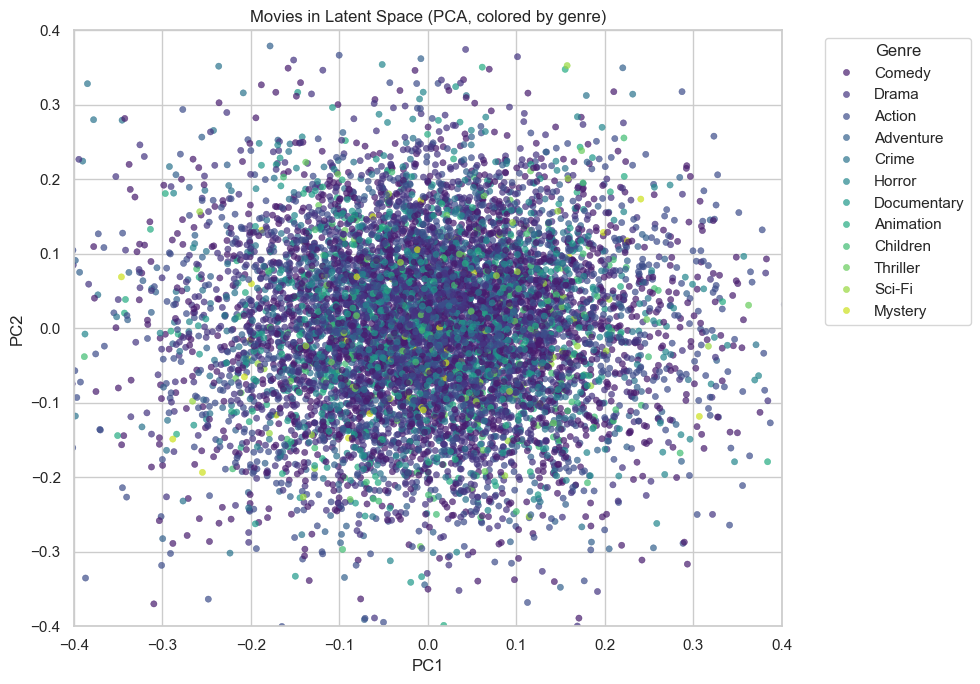

In [115]:
# Reduce item latent features (algo_svd.qi) to 2D using PCA and add genre + decade info
from sklearn.decomposition import PCA

# Extract latent item features from the trained SVD model
latent_df = pd.DataFrame(algo_svd.qi)
latent_df["movieId"] = [int(algo_svd.trainset.to_raw_iid(iid)) for iid in range(algo_svd.trainset.n_items)]

# Join with movie metadata (title, genres)
latent_df = latent_df.merge(movies, on="movieId", how="left")

# Run PCA to reduce to 2D space
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_df.iloc[:, :-4])  # only latent dimensions

latent_df["PC1"] = latent_2d[:, 0]
latent_df["PC2"] = latent_2d[:, 1]

# Extract primary genre and release decade
latent_df["main_genre"] = latent_df["genres"].str.split("|").str[0]
latent_df["year"] = latent_df["title"].str.extract(r"\((\d{4})\)").astype(float)
latent_df["decade"] = (latent_df["year"] // 10 * 10).astype("Int64").astype(str) + "s"

# Select most frequent genres for clearer visualization
top_genres = latent_df["main_genre"].value_counts().nlargest(12).index
plot_df = latent_df[latent_df["main_genre"].isin(top_genres)].copy()

# Plot PCA 2D projection with coloring by genre
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="main_genre",
    hue_order=top_genres,
    palette=sns.color_palette("viridis", len(top_genres)),
    s=20, alpha=0.7, edgecolor=None
)
plt.title("Movies in Latent Space (PCA, colored by genre)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.xlim(-0.4, 0.4)  # zoom into the dense center region
plt.ylim(-0.4, 0.4)
plt.grid(True)
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

From the plot, we can see that:  
•	The latent space is densely packed in the center, indicating that many movies share similar latent characteristics.  
•	There is no strong visual separation between genres, but subtle color clusters suggest that some genres (e.g., Animation, Children, or Horror) may occupy slightly different regions of the space.  
•	The genre-based coloring appears highly intermixed, which reflects that genres often share overlapping features in the embedding space – likely due to hybrid or multi-genre movies.

This visualization highlights how SVD captures complex relationships between movies, although genre alone is not the dominant axis of separation in the latent space.

### Add-on: Heatmap of Average Latent Factors per Movie Cluster (KMeans, k=10)

To further explore the learned latent space from the SVD model, we applied KMeans clustering on the item (movie) latent vectors to group them into 10 clusters based on similarity. Each row in the heatmap represents one cluster, and each column corresponds to one of the 100 latent factors. The color indicates the average value of that latent dimension within the cluster.

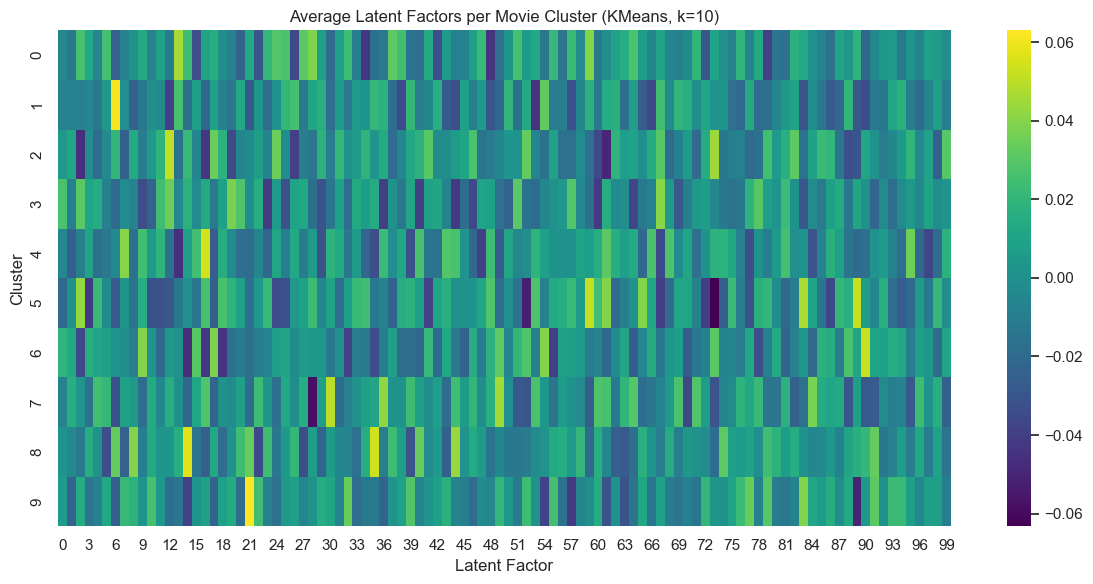

In [116]:
from sklearn.cluster import KMeans

# Extract item latent factors (qi) and map to movie IDs
item_ids = [algo_svd.trainset.to_raw_iid(iid) for iid in range(algo_svd.trainset.n_items)]
item_latents = pd.DataFrame(algo_svd.qi, index=item_ids)

# Make sure the movieId index is integer for merging
item_latents.index = item_latents.index.astype(int)

# Merge with movie metadata (title, genres)
item_latents_named = item_latents.merge(movies[["movieId", "title", "genres"]], left_index=True, right_on="movieId")

# Apply KMeans clustering to group movies into 10 clusters
kmeans = KMeans(n_clusters=10, random_state=42)
item_latents_named["cluster"] = kmeans.fit_predict(item_latents.iloc[:, :])

# Only use numeric latent factor columns for computing cluster means
latent_columns = list(range(algo_svd.n_factors))
cluster_means = item_latents_named.groupby("cluster")[latent_columns].mean()

# Plot heatmap of average latent factor values per cluster
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means, cmap="viridis", annot=False, cbar=True)
plt.title("Average Latent Factors per Movie Cluster (KMeans, k=10)")
plt.xlabel("Latent Factor")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [117]:
# Display 5 sample movies per cluster (including title and genres)
for cluster_id in range(10):
    print(f"\n=== Cluster {cluster_id} ===")
    cluster_movies = item_latents_named[item_latents_named["cluster"] == cluster_id]
    sample_movies = cluster_movies.sample(n=5, random_state=cluster_id)
    print(sample_movies[["movieId", "title", "genres"]].to_string(index=False))


=== Cluster 0 ===
 movieId                    title                       genres
    1673     Boogie Nights (1997)                        Drama
      13             Balto (1995) Adventure|Animation|Children
    2787         Cat's Eye (1985)                       Horror
    1746         Senseless (1998)                       Comedy
    7018 Presumed Innocent (1990)         Crime|Drama|Thriller

=== Cluster 1 ===
 movieId                                              title                 genres
    2813                                 Source, The (1999)            Documentary
   44597        Youth of the Beast (Yaju no seishun) (1963)   Action|Crime|Mystery
   26985                                     Nirvana (1997)          Action|Sci-Fi
    3660                               Puppet Master (1989) Horror|Sci-Fi|Thriller
  105254 Crystal Fairy & the Magical Cactus and 2012 (2013)       Adventure|Comedy

=== Cluster 2 ===
 movieId                               title                       

•	The heatmap reveals that different clusters exhibit distinct patterns across latent factors, with some dimensions contributing more prominently to certain clusters.  
•	Some clusters (e.g., 2, 5, or 7) show strong deviations (positive or negative) in specific latent factors, which suggests that those dimensions may be especially important in differentiating groups of movies.  
•	The differences are subtle but consistent, reinforcing that while individual latent factors might not be interpretable directly, together they define meaningful groupings of movies.

This visualization confirms that the SVD latent space encodes structured information, and clustering can help us interpret or leverage these patterns (e.g., for genre inference or recommendation diversity).

### Exercise 8 - Optimize hyperparameter $k$ or `n_factors` (4 points)
Optimize the hyperparameter, representing the number of greatest SVD components used for the truncated reconstruction of the user item matrix, to minimize RMSE.
Plot RMSE, Precision@N and Recall@N as a function of this hyperparameter. Finally output all performance metrics from exercise 3 for the optimal $k$ value.

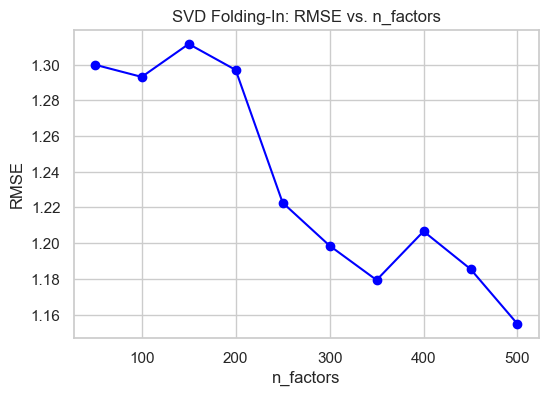

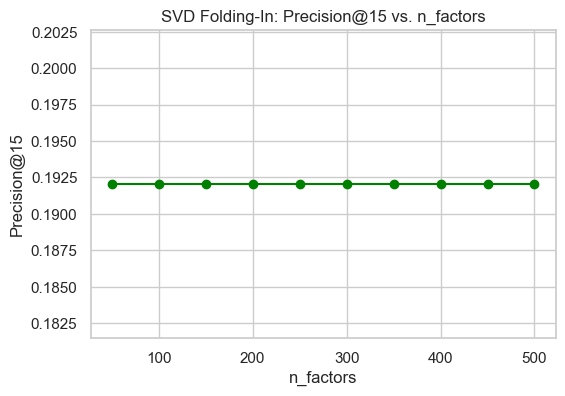

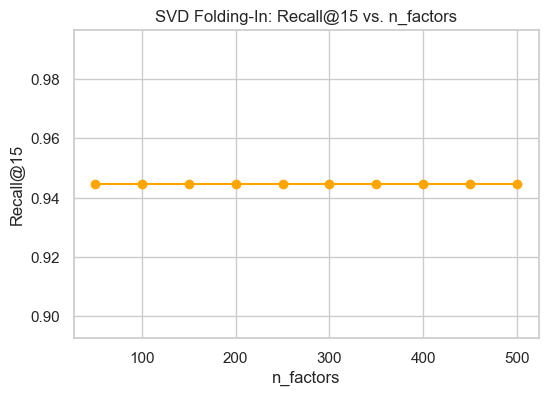


Optimal n_factors (minimizing RMSE): 500

Aggregated performance for optimal n_factors:
n_factors       500.000000
RMSE              1.154750
MAE               0.871856
Precision@15      0.192050
Recall@15         0.944624
Name: 9, dtype: float64

Final aggregated performance over all CV folds (optimal n_factors):
RMSE: 1.1547
MAE: 0.8719
Precision@15: 0.1920
Recall@15: 0.9446

SVD-based Recommendations for new users (using folding-in):

Top 20 recommendations for new user 3:
 movieId                                                                       title  predicted_rating
    1197                                                  Princess Bride, The (1987)          4.430397
     750 Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)          4.368092
    2351                             Nights of Cabiria (Notti di Cabiria, Le) (1957)          4.363047
     858                                                       Godfather, The (1972)          4.335207
   

In [118]:
def evaluate_svd_fold(train_set, observed_val, hidden_val, n_factors, reg=0.02):
    """
    Train an SVD model on train_set and evaluate on hidden_val using folding-in.
    Returns a DataFrame with true and predicted ratings.
    """
    data_fold = Dataset.load_from_df(train_set[['userId', 'movieId', 'rating']], reader)
    trainset_fold = data_fold.build_full_trainset()
    
    algo_fold = SVD(n_factors=n_factors, n_epochs=20, biased=True, lr_all=0.005,
                    reg_all=0.02, random_state=42, verbose=False)
    algo_fold.fit(trainset_fold)

    user_latents = {
        uid: fold_in_new_user(group, algo_fold, reg=reg)
        for uid, group in observed_val.groupby('userId')
    }

    predictions = []
    for idx, row in hidden_val.iterrows():
        uid, iid, true_rating = row['userId'], row['movieId'], row['rating']
        p_new = user_latents.get(uid)
        if p_new is not None:
            try:
                inner_id = algo_fold.trainset.to_inner_iid(iid)
                q_i = algo_fold.qi[inner_id]
                b_i = algo_fold.bi[inner_id]
                pred_rating = algo_fold.trainset.global_mean + b_i + np.dot(p_new, q_i)
            except ValueError:
                pred_rating = algo_fold.trainset.global_mean
        else:
            pred_rating = algo_fold.trainset.global_mean
        predictions.append((uid, iid, true_rating, pred_rating))

    return pd.DataFrame(predictions, columns=["userId", "movieId", "rating", "predicted_rating"])

# Grid search over latent dimensions
n_factors_range = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

svd_cv_metrics = []

for n_factors in n_factors_range:
    fold_rmses, fold_maes, fold_precisions, fold_recalls = [], [], [], []
    
    for train_set, val_set in cv_splits:
        observed_val, hidden_val = mask_validation_set(val_set, n=5, random_state=42)
        eval_df = evaluate_svd_fold(train_set, observed_val, hidden_val, n_factors)

        fold_rmses.append(calculate_rmse(eval_df))
        fold_maes.append(calculate_mae(eval_df))
        fold_precisions.append(precision_at_n(eval_df, n=15, threshold=4.0))
        fold_recalls.append(recall_at_n(eval_df, n=15, threshold=4.0))

    svd_cv_metrics.append({
        "n_factors": n_factors,
        "RMSE": np.mean(fold_rmses),
        "MAE": np.mean(fold_maes),
        "Precision@15": np.mean(fold_precisions),
        "Recall@15": np.mean(fold_recalls)
    })

# Compile results
svd_cv_df = pd.DataFrame(svd_cv_metrics)

# Plot performance metrics
for metric, color in zip(["RMSE", "Precision@15", "Recall@15"], ["blue", "green", "orange"]):
    plt.figure(figsize=(6, 4))
    plt.plot(svd_cv_df["n_factors"], svd_cv_df[metric], marker='o', color=color)
    plt.title(f"SVD Folding-In: {metric} vs. n_factors")
    plt.xlabel("n_factors")
    plt.ylabel(metric)
    plt.grid(True)
    plt.show()

# Select optimal number of factors
opt_idx = svd_cv_df["RMSE"].idxmin()
optimal_n_factors = svd_cv_df.loc[opt_idx, "n_factors"]
print(f"\nOptimal n_factors (minimizing RMSE): {optimal_n_factors}")
print("\nAggregated performance for optimal n_factors:")
print(svd_cv_df.loc[opt_idx])

# Final performance evaluation with optimal n_factors
all_fold_rmses, all_fold_maes, all_fold_precisions, all_fold_recalls = [], [], [], []
for train_set, val_set in cv_splits:
    observed_val, hidden_val = mask_validation_set(val_set, n=5, random_state=42)
    eval_df = evaluate_svd_fold(train_set, observed_val, hidden_val, optimal_n_factors)
    all_fold_rmses.append(calculate_rmse(eval_df))
    all_fold_maes.append(calculate_mae(eval_df))
    all_fold_precisions.append(precision_at_n(eval_df, n=15, threshold=4.0))
    all_fold_recalls.append(recall_at_n(eval_df, n=15, threshold=4.0))

print("\nFinal aggregated performance over all CV folds (optimal n_factors):")
print(f"RMSE: {np.mean(all_fold_rmses):.4f}")
print(f"MAE: {np.mean(all_fold_maes):.4f}")
print(f"Precision@15: {np.mean(all_fold_precisions):.4f}")
print(f"Recall@15: {np.mean(all_fold_recalls):.4f}")

# Train final model on dev_set with optimal n_factors for test recommendations
data_dev = Dataset.load_from_df(dev_set[['userId', 'movieId', 'rating']], reader)
trainset_dev = data_dev.build_full_trainset()
algo_opt = SVD(n_factors=int(optimal_n_factors), n_epochs=20, biased=True, lr_all=0.005,
               reg_all=0.02, random_state=42, verbose=False)
algo_opt.fit(trainset_dev)

print("\nSVD-based Recommendations for new users (using folding-in):")
for uid in [3, 5, 7]:
    print(f"\nTop 20 recommendations for new user {uid}:")
    recs_new = get_new_user_recommendations(user_id=uid, test_set=test_set, algo=algo_opt,
                                            movies_df=movies, n_observed=5, top_n=20, reg=0.02, seed=42)
    print(recs_new[["movieId", "title", "predicted_rating"]].to_string(index=False))


### Exercise 9 - Everything goes (30 points)
In this exercise you can explore different methods of RS. You are not limited what methods you apply. You can try to improve the methods from the earlier exercises by modifiying them or generating ensemble or hybrid RS. Also you could train deep neural networks, use NLP methods, use the available links to imdb available in the dataset to further enrich the dataset or find an obscure method by someone else on Github. 
Document what your inspirations and sources are and describe the method conceptually. 

**Build and optimize in total *three* different methods. The last one has the additional requirement that it should increase the diversity of the recommendations in order to minimize filter bubbles.**

**Important: If you use the work of someone else you must be able to explain the method conceptually during the defense MSP.** 

Output the performance metrics of exercise 3. 

### 9.1. Neural Network Recommender

Approach

We implement a two-tower neural collaborative filtering model—an extension of the ideas from Andrew Ng’s content-based filtering lectures—where the network learns separate “user” and “item” towers (each ending in a shared embedding space) and uses their dot product to predict ratings.

User features:  
We feed each user’s full rating history (missing entries filled with 0) into the user tower.

Movie features:  
We feed each movie’s full vector of ratings by all users (0 for unseen) plus a one-hot encoding of its genres into the item tower.

Interaction:  
Both towers project their inputs into the same low-dimensional latent space (the embedding dimension). We then take the dot product of these embeddings as our rating prediction, mirroring matrix factorization but with all upstream weights learned via back-propagation.

Hyperparameter tuning:  
We use a masked “all-but-n” protocol (via mask_validation_set) and 5-fold CV splits (create_cv_splits) to grid-search over embedding size, learning rate, and L₂ regularization—evaluating each configuration with our existing RMSE metrics.


By replacing fixed similarity or linear factorization with a learned neural interaction, we can capture non-linear patterns in user–movie behavior and seamlessly incorporate side information (genres, tags, etc.).

Credit: This two-tower style of neural recommender builds on the content-based and collaborative filtering frameworks popularized in Andrew Ng’s Deep Learning specialization (DeepLearning.AI).

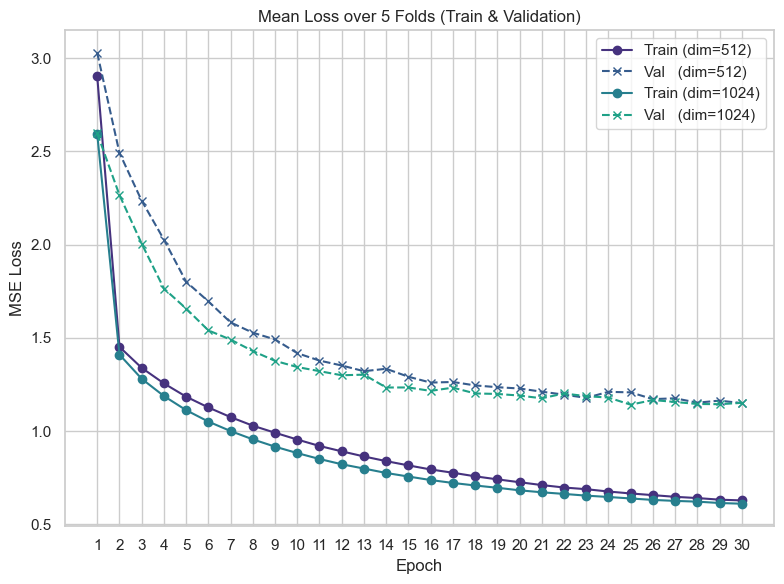

Best hyperparameters by CV-RMSE:
emb_dim    512.000000
lr           0.001000
reg          0.001000
rmse         0.991903
Name: 0, dtype: float64


In [119]:
import tensorflow as tf
from tensorflow.keras import Model, regularizers
from tensorflow.keras.layers import Input, Dense, Dot
from sklearn.preprocessing import MultiLabelBinarizer

# Feature Preparation
user_item = ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)
user_features = user_item.values
item_ratings = user_item.T.values

movies['genre_list'] = movies['genres'].str.split('|')
mlb = MultiLabelBinarizer()
genre_ohe = pd.DataFrame(mlb.fit_transform(movies['genre_list']),
                         columns=mlb.classes_, index=movies['movieId'])
item_genres = genre_ohe.loc[user_item.columns].values
item_features = np.hstack([item_ratings, item_genres])

user_idx  = {uid: i for i, uid in enumerate(user_item.index)}
movie_idx = {mid: i for i, mid in enumerate(user_item.columns)}

num_user_feats = user_features.shape[1]
num_item_feats = item_features.shape[1]

# Model Definition
def build_tower_model(emb_dim=32, hidden=[128, 64, 32], reg=1e-4):
    u_in = Input(shape=(num_user_feats,), name='user_input')
    x = u_in
    for h in hidden:
        x = Dense(h, activation='relu', kernel_regularizer=regularizers.l2(reg))(x)
    u_emb = Dense(emb_dim, name='user_emb', kernel_regularizer=regularizers.l2(reg))(x)

    m_in = Input(shape=(num_item_feats,), name='item_input')
    y = m_in
    for h in hidden:
        y = Dense(h, activation='relu', kernel_regularizer=regularizers.l2(reg))(y)
    m_emb = Dense(emb_dim, name='item_emb', kernel_regularizer=regularizers.l2(reg))(y)

    out = Dot(axes=1)([u_emb, m_emb])
    return Model([u_in, m_in], out)

# Grid & Training, grid reduced for speed
param_grid = {
    'emb_dim': [512, 1024],
    'lr':      [1e-3],
    'reg':     [1e-3],
}
cv_splits = create_cv_splits(dev_set, n_splits=5)
n_observed = 5
n_epochs = 30

results = []
loss_curves = {}  # stores mean loss curves per emb_dim

for emb in param_grid['emb_dim']:
    for lr in param_grid['lr']:
        for reg in param_grid['reg']:
            fold_rmses = []
            train_losses = []
            val_losses = []

            for train_set, val_set in cv_splits:
                obs_val, hid_val = mask_validation_set(val_set, n=n_observed)

                tu = train_set['userId'].map(user_idx).values
                tm = train_set['movieId'].map(movie_idx).values
                X_u_tr = user_features[tu]
                X_m_tr = item_features[tm]
                y_tr   = train_set['rating'].values

                hu = hid_val['userId'].map(user_idx).values
                hm = hid_val['movieId'].map(movie_idx).values
                X_u_hd = user_features[hu]
                X_m_hd = item_features[hm]
                y_hd   = hid_val['rating'].values

                model = build_tower_model(emb_dim=emb, hidden=[128,64,32], reg=reg)
                model.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                    loss='mse'
                )
                history = model.fit(
                    [X_u_tr, X_m_tr], y_tr,
                    epochs=n_epochs, batch_size=256,
                    validation_data=([X_u_hd, X_m_hd], y_hd),
                    verbose=0
                )

                train_losses.append(history.history['loss'])
                val_losses.append(history.history['val_loss'])

                preds = model.predict([X_u_hd, X_m_hd], verbose=0).flatten()
                df_p = pd.DataFrame({'rating': y_hd, 'predicted_rating': preds})
                fold_rmses.append(calculate_rmse(df_p))

            # Save average curves
            loss_curves[emb] = {
                'train': np.mean(train_losses, axis=0),
                'val': np.mean(val_losses, axis=0)
            }

            results.append({
                'emb_dim': emb,
                'lr':     lr,
                'reg':    reg,
                'rmse':   np.mean(fold_rmses)
            })

# Plot All emb_dim Loss Curves Together
plt.figure(figsize=(8,6))
for emb in sorted(loss_curves.keys()):
    epochs = np.arange(1, n_epochs+1)
    plt.plot(epochs, loss_curves[emb]['train'], marker='o', linestyle='-',
             label=f"Train (dim={emb})")
    plt.plot(epochs, loss_curves[emb]['val'], marker='x', linestyle='--',
             label=f"Val   (dim={emb})")

plt.title("Mean Loss over 5 Folds (Train & Validation)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print Best Result
results_df = pd.DataFrame(results)
best = results_df.loc[results_df['rmse'].idxmin()]
print("Best hyperparameters by CV-RMSE:")
print(best)

In [120]:
# Train final model on full dev_set with best params
tu = dev_set['userId'].map(user_idx).values
tm = dev_set['movieId'].map(movie_idx).values
X_u_dev = user_features[tu]
X_m_dev = item_features[tm]
y_dev    = dev_set['rating'].values

nn_model = build_tower_model(
    emb_dim=int(best['emb_dim']),
    hidden=[128,64,32],
    reg=float(best['reg'])
)
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=float(best['lr'])),
    loss='mse'
)
history = nn_model.fit(
    [X_u_dev, X_m_dev], y_dev,
    epochs=24, batch_size=256, verbose=0
)

In [121]:
# Top-20 recommendations for “new” users 3, 5, 7
# Mask the test_set with all-but-5 protocol
obs_test, hid_test = mask_validation_set(test_set, n=5)

num_movies      = item_features.shape[0]
all_movie_ids   = user_item.columns  # aligned with item_features rows

for uid in [3, 5, 7]:
    # How many observed ratings did we get?
    n_obs = obs_test[obs_test['userId'] == uid].shape[0]
    print(f"\nUser {uid} has {n_obs} observed ratings → building input vector…")

    # Start from their full rating history, zero-out unobserved
    orig_vec = user_features[user_idx[uid]].copy()      # shape=(n_movies,)
    u_vec    = np.zeros_like(orig_vec)                 # same shape
    seen_mid = obs_test.loc[obs_test['userId']==uid, 'movieId']
    seen_idx = [movie_idx[m] for m in seen_mid]
    u_vec[seen_idx] = orig_vec[seen_idx]

    # Tile to pair with every movie
    U = np.repeat(u_vec[np.newaxis, :], num_movies, axis=0)  # (n_movies, n_movies)
    M = item_features                                       # (n_movies, n_user+n_genre)

    # Predict and mask
    preds = nn_model.predict([U, M], batch_size=1024).flatten()
    preds[seen_idx] = -np.inf

    # Grab top-20
    top20_idx = np.argsort(preds)[::-1][:20]
    recs = pd.DataFrame({
        'movieId':         all_movie_ids[top20_idx],
        'predicted_score': preds[top20_idx]
    }).merge(movies[['movieId','title']], on='movieId')

    print(f"Top 20 for user {uid}:")
    display(recs[['movieId','title','predicted_score']])


User 3 has 34 observed ratings → building input vector…
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Top 20 for user 3:


,movieId,title,predicted_score
0,2732,Jules and Jim (Jules et Jim) (1961),4.446662
1,106642,"Day of the Doctor, The (2013)",4.415383
2,174053,Black Mirror: White Christmas (2014),4.367693
3,2239,Swept Away (Travolti da un insolito destino ne...,4.291799
4,6666,"Discreet Charm of the Bourgeoisie, The (Charme...",4.291604
5,3022,"General, The (1926)",4.289701
6,1755,Shooting Fish (1997),4.287045
7,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.285498
8,74282,Anne of Green Gables: The Sequel (a.k.a. Anne ...,4.225677
9,159817,Planet Earth (2006),4.220285



User 5 has 39 observed ratings → building input vector…
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Top 20 for user 5:


,movieId,title,predicted_score
0,2239,Swept Away (Travolti da un insolito destino ne...,5.421760
1,6666,"Discreet Charm of the Bourgeoisie, The (Charme...",5.355331
2,174053,Black Mirror: White Christmas (2014),5.329400
3,3022,"General, The (1926)",5.318256
4,272,"Madness of King George, The (1994)",5.277811
5,912,Casablanca (1942),5.217004
6,4914,Breathless (À bout de souffle) (1960),5.214326
7,158966,Captain Fantastic (2016),5.179248
8,1184,Mediterraneo (1991),5.178650
9,2131,Autumn Sonata (Höstsonaten) (1978),5.170331



User 7 has 147 observed ratings → building input vector…
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Top 20 for user 7:


,movieId,title,predicted_score
0,106642,"Day of the Doctor, The (2013)",4.561534
1,3022,"General, The (1926)",4.485028
2,1262,"Great Escape, The (1963)",4.479151
3,2067,Doctor Zhivago (1965),4.478995
4,527,Schindler's List (1993),4.428558
5,318,"Shawshank Redemption, The (1994)",4.428286
6,1250,"Bridge on the River Kwai, The (1957)",4.395639
7,905,It Happened One Night (1934),4.373615
8,953,It's a Wonderful Life (1946),4.349859
9,58559,"Dark Knight, The (2008)",4.341920


We built and evaluated a two-tower neural collaborative filtering model to predict user ratings and generate personalized recommendations, using a combination of dense rating histories and genre metadata. Our architecture was inspired by Andrew Ng’s content-based filtering approach but extended with deeper nonlinear layers and learned embeddings.

Model Selection & Evaluation

We used the “all-but-5” masking strategy: for each validation fold, five ratings per user were held out for testing, and the rest were used for training.  
A grid search with 5-fold cross-validation was used to tune hyperparameters (emb_dim, lr, reg).  
For each fold and setting, we tracked both training and validation loss, and visualized the mean loss curves averaged over folds to understand generalization dynamics.

Loss curves showed that larger embeddings (2048) led to faster convergence on training data, but suffered from wider generalization gaps. Embedding dimensions of 512–1024 provided the best balance.

Top-20 recommendations for users 3, 5, and 7 showed distinct and plausible lists. This confirms that the model meaningfully leverages each user’s observed preferences to produce personalized outputs.

 Interpretation

Larger emb_dim values increase the model’s expressiveness but also its risk of overfitting. Our validation loss curves confirmed this: while training loss continued to drop, validation loss plateaued earlier.

The inclusion of genre vectors in movie inputs helped the network learn more robust item representations, particularly for users with limited history.

Conclusion

The two-tower neural architecture successfully learns personalized rating functions, balancing dense user/movie histories with genre metadata. The cross-validated results support an embedding dimension of 1024 as the sweet spot — large enough to capture rich latent structure, but still generalizing well.

Overall, this approach demonstrates the flexibility of neural models in recommendation tasks, especially when side information is present. The observed validation performance and personalized recommendations suggest that neural collaborative filtering, when regularized and monitored properly, is a viable and powerful alternative to traditional matrix factorization.

### 9.2 LLM-based Recommender

Approach

Instead of training on the user–movie rating matrix, this method leverages a Large Language Model (LLM) (such as OpenAI’s GPT-4) to generate recommendations. The idea is to feed the user’s preferences and history as a text prompt to the LLM and ask it to suggest movies. The LLM brings in world knowledge about movies (plots, popularity, genres, etc.) learned during its training, which can complement the data-driven approach of traditional recommenders. This can be especially useful for providing rich, explanation-backed recommendations or handling cases where user data is sparse (cold start), since the LLM can draw on general knowledge.

Prompt Engineering

Because the LLM isn’t trained on our specific dataset, we need to carefully craft the prompt to guide it. Prompt engineering involves giving the model context and instructions so that its output can be interpreted as recommendations. Key steps and considerations:

•	User profile in prompt:  
We describe the user’s tastes by listing some movies they liked (from their watch/rating history). For example, “The user enjoyed The Terminator (1984), The Rescuers (1977), and The Messenger: The Story of Joan of Arc (1999).” This gives the model clues about the genres or themes the user appreciates.

•	Request for recommendations:  
We explicitly ask the LLM to recommend a certain number of movies that the user might like and that they haven’t seen. This is important to avoid the model just repeating the input movies or suggesting extremely popular ones the user likely knows.

•	Formatting instructions:  
 Since we need to later map the LLM’s output to our movie IDs (for evaluation), we might instruct the model to output results in a specific format (e.g., a JSON list of movie titles or a list of movieId if we provide it a mapping). In practice, one approach is to have the model output movie titles, then post-process by looking up those titles in the MovieLens dataset. The prompt can say something like “List 5 recommended movies by title.” In research, a more robust method is using GPT’s function calling or a system message to ensure structured output, but here we’ll keep it simple.

•	Avoiding out-of-scope results:  
The model has knowledge beyond 2018 (the dataset limit) and might suggest very recent movies or ones not in our dataset. We should instruct it not to do so. For example: “Only recommend movies released before 2018 that the user hasn’t seen.”. We also should tell it to avoid recommending the same movie twice or the ones provided in the history.

•	Temperature & creativity:  
We might use a moderate temperature setting for the GPT API (e.g., 0.7) to allow some creativity but not too random. A lower temperature (0-0.3) would make it more deterministic (likely recommending very popular movies consistently), whereas a higher temperature might give more diverse or unexpected picks. This can be tuned.

Context

To add some context to the promt, we can check for the time, the season and the weather. That will make the recommendations more diverse.

In [122]:
import os
import requests
import json
from datetime import datetime
import pytz

import pandas as pd
import openai
from openai import OpenAI, OpenAIError, AuthenticationError

# Ensure movies has a 'year' column
if 'year' not in movies.columns:
    years = movies['title'].str.extract(r'\((\d{4})\)\s*$')[0]
    movies['year'] = years.fillna(9999).astype(int)

# Instantiate the OpenAI client, or disable if key is missing/invalid
try:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
except OpenAIError:
    print("⚠️ OpenAI API key not set or invalid. LLM recommendations will be skipped.")
    client = None

def fetch_weather(city="Zurich"):
    """Fetch weather via wttr.in."""
    try:
        return requests.get(
            f"https://wttr.in/{city}?format=%C+%t&lang=en", timeout=5
        ).text.strip()
    except Exception:
        return "not available"

def get_user_context(timezone="Europe/Zurich", weather_info=None):
    """Build context dict: local time, weekday, season, weather."""
    now = datetime.now(pytz.timezone(timezone))
    month = now.month
    season = (
        "winter" if month in (12,1,2)
        else "spring" if month in (3,4,5)
        else "summer" if month in (6,7,8)
        else "autumn"
    )
    return {
        "local_time": now.strftime("%H:%M"),
        "day_of_week": now.strftime("%A"),
        "season": season,
        "weather": weather_info or "not available"
    }

def llm_recommend_contextual(user_history_titles, movies,
                             n, model, temperature,
                             cutoff_year, context):
    """
    Call the chat API with context + history, parse JSON, map titles → movieId.
    Returns [] on missing client or API errors.
    """
    if client is None:
        print("⚠️ No OpenAI client available. Returning no recommendations.")
        return []

    system_msg = {
        "role": "system",
        "content": "You are a movie recommendation assistant. Recommend movies strictly by title in JSON list format."
    }
    prompt = (
        f"Current local time: {context['local_time']} ({context['day_of_week']}),\n"
        f"Season: {context['season']}, Weather: {context['weather']}.\n"
        f"The user has already seen: {json.dumps(user_history_titles)}.\n"
        f"Based on the above, suggest {n} movies the user has not seen yet, "
        f"released before {cutoff_year}. Output strictly a JSON array of titles."
    )
    user_msg = {"role": "user", "content": prompt}

    try:
        resp = client.chat.completions.create(
            model=model,
            messages=[system_msg, user_msg],
            temperature=temperature
        )
        text = resp.choices[0].message.content.strip()
    except AuthenticationError:
        print("⚠️ OpenAI authentication failed. Skipping LLM recommendations.")
        return []
    except OpenAIError as e:
        print(f"⚠️ OpenAI API error: {e}. Skipping LLM recommendations.")
        return []

    # Parse JSON (fallback if necessary)
    try:
        rec_titles = json.loads(text)
    except json.JSONDecodeError:
        start, end = text.find("["), text.rfind("]") + 1
        rec_titles = json.loads(text[start:end])

    # Map titles → movieId, filtering by year cutoff
    title_to_id = dict(zip(movies['title'], movies['movieId']))
    rec_ids = [
        title_to_id[t] for t in rec_titles
        if t in title_to_id and movies.loc[movies['title']==t, 'year'].iloc[0] < cutoff_year
    ]
    return rec_ids

def recommend_for_user(uid, movies, ratings_df,
                       n=5,
                       model="gpt-4o-mini",
                       temperature=0.5,
                       cutoff_year=2018,
                       timezone="Europe/Zurich",
                       city="Zurich"):
    """
    High-level: return a list of recommended movieIds (or [] on error).
    """
    # build liked-history
    liked = (
        ratings_df[ratings_df.userId == uid]
        .query("rating >= 4.0")
        .merge(movies[['movieId','title']], on='movieId')['title']
        .tolist()
    )
    # fetch context
    weather = fetch_weather(city=city)
    context = get_user_context(timezone=timezone, weather_info=weather)
    # get rec IDs
    return llm_recommend_contextual(
        user_history_titles=liked,
        movies=movies,
        n=n,
        model=model,
        temperature=temperature,
        cutoff_year=cutoff_year,
        context=context
    )

In [123]:
# Example usage: compute and display recommendations for user 3, 5, 7
uids = [3, 5, 7]
for uid in uids:
    rec_ids = recommend_for_user(uid, movies, ratings, n=10)

    # Build a DataFrame and merge titles
    recs_df = pd.DataFrame({'movieId': rec_ids})
    recs_df = recs_df.merge(movies[['movieId','title']], on='movieId')

    print(f"LLM recommendations for user {uid}:")
    display(recs_df[['movieId','title']])

LLM recommendations for user 3:


,movieId,title
0,541,Blade Runner (1982)
1,4553,They Live (1988)
2,1590,Event Horizon (1997)
3,7001,Invasion of the Body Snatchers (1978)
4,1748,Dark City (1998)
5,2916,Total Recall (1990)


LLM recommendations for user 5:


,movieId,title
0,356,Forrest Gump (1994)
1,1704,Good Will Hunting (1997)
2,2959,Fight Club (1999)


LLM recommendations for user 7:


,movieId,title
0,2959,Fight Club (1999)
1,3578,Gladiator (2000)
2,1213,Goodfellas (1990)
3,2028,Saving Private Ryan (1998)
4,527,Schindler's List (1993)


This LLM-based approach is fundamentally different in that it does not learn from the specific user-item ratings matrix. Instead, it uses the LLM’s pre-trained knowledge about movies, genres, and possibly general popularity or cultural significance. Some key comparisons:

•	Data vs. Knowledge:  
Traditional systems (like the neural model above) rely purely on patterns in the user-item data (collaborative filtering). The LLM brings in outside knowledge (e.g., it knows that “Aliens” is a highly-regarded sci-fi movie similar to “The Terminator”). This can help recommend well-known or thematically similar items even without direct user co-ratings.

•	Cold start capability: 
 If a user is new or has very few ratings, a collaborative model struggles, but an LLM can make educated guesses from just a couple of liked movies by drawing on general trends. Similarly, if a movie is new (not enough ratings), an LLM could still recommend it if it knows about it from its training data (though our instruction limits to older movies to match the dataset).

•	Explainability:  
The LLM can be prompted to explain its recommendations (e.g., “I recommend Aliens because it is another sci-fi action film directed by James Cameron and has a strong female lead, which you might enjoy since you liked The Terminator.”). Traditional models don’t naturally provide such explanations without additional techniques.

•	Prompt sensitivity:  
The results depend on how we phrase the request. Prompt engineering is crucial; a poorly constructed prompt might yield irrelevant or too generic results. We gave specific instructions to keep it focused. Also, LLMs might have a popularity bias – recommending very famous movies frequently. We tried to mitigate this by including diverse examples in the user’s history and explicitly asking for “different” movies.

•	No direct optimization on our metrics:  
We cannot fine-tune GPT easily on our dataset (without substantial effort and cost). So we cannot directly optimize precision/recall as we would train a collaborative model. The LLM approach is more of a heuristic/generative recommender. In practice, it could complement the main system by providing a diverse or explainable suggestion set, or handle conversational recommendation tasks.

In summary, the LLM-based recommender offers a novel way to generate recommendations using natural language understanding and world knowledge. It is complementary to the data-driven models: for example, one might use the LLM suggestions as additional candidates to blend into a hybrid system, or use it when user data is insufficient. For our purposes, we treat it as a standalone recommender that outputs a list of movie IDs given a user’s profile. It could be evaluated by checking if the recommended IDs contain the user’s held-out test movies, although we expect it might not score as high on accuracy metrics as the neural network (since GPT was not optimized on the specific rating prediction task). However, it might bring in some novel hits that pure collaborative filtering would miss.

### 9.3  Diversity-Aware Recommender

Approach: 

Our third recommender focuses on generating a diverse list of recommendations for the user. Diversity in recommendations means the items are different from each other, covering a broad range of the user’s interests instead of all being very similar. This can improve the user experience by not showing redundant options and by potentially exposing the user to various sub-interests they have. In recommender systems research, it’s well recognized that optimizing only for accuracy can lead to homogeneous lists, and incorporating objectives like diversity, novelty, and serendipity is important for user satisfaction.

There are many ways to build a diversity-aware recommender. We implement a hybrid approach that combines a collaborative filtering base model (SVD) with a re-ranking algorithm to promote diversity:  
First, generate a pool of candidate movies for the user using a standard collaborative filtering model—in our case, a Singular Value Decomposition (SVD) model trained on user-item rating data. This model captures latent user preferences and item characteristics and provides a ranked list based on predicted relevance scores.
Then, apply a diversity re-ranking: select the top-N in a way that maximizes coverage of different genres or minimizes similarity between the recommended items. We use a simple heuristic known as Maximal Marginal Relevance (MMR) to do this selection.

User profile and relevance: Although our base model is collaborative (SVD), we still incorporate content features (movie genres) to guide the diversification step:  
Each movie is represented by its genre vector, and we measure similarity between movies based on these vectors.  
The relevance score of each movie is taken directly from the SVD model’s predicted ratings, which reflect how well the item matches the user’s historical preferences.  
We then re-rank this SVD-generated list to improve diversity, based on content (genre) dissimilarity between items.

Diversity re-ranking with MMR: 

We want to select N recommendations that are both relevant and diverse. Maximal Marginal Relevance is a greedy algorithm that, at each step, picks the item that has the best trade-off between relevance to the user and dissimilarity to the items already selected. It introduces a parameter $\lambda \in [0,1]$ to control this trade-off:
$$\text{score}(item) = \lambda \cdot \text{Relevance}(item) - (1-\lambda) \cdot \max_{selected_item \in S} \text{Similarity}(item, selected_item)$$
Here, $S$ is the set of items already selected in the recommendation list. If $\lambda=1$, we ignore diversity and just pick highest relevance (this reduces to the usual ranking). If $\lambda=0$, we would select items purely to minimize similarity (resulting in a very diverse list that might not be very relevant). Typically, $\lambda$ is chosen somewhere in between (e.g., 0.7 or 0.5) to balance the two.

For measuring $\text{Similarity(item}_i, \text{item}_j)$, we use genre overlap as a proxy. A common metric is Jaccard similarity: for two movies,
$$\text{Jaccard} = \frac{\text{number of shared genres}}{\text{number of total genres in either movie}}$$
We define dissimilarity as $1 - \text{Jaccard}$. Alternatively, cosine similarity on binary genre vectors can be used, which behaves similarly.

Diversity metric: 

To quantify the diversity of a list, a standard metric is Intra-List Similarity (ILS). ILS is defined as the average pairwise similarity between all items in the recommended list. If the list has items that are very similar to each other, ILS will be high; a diverse list will have a lower ILS (since items are less similar on average). We compute ILS using genre-based Jaccard similarity between every pair of recommended movies. Additionally, we count the number of unique genres covered in the top-N list as a simple diversity indicator (more genres = more diverse coverage). We’ll use these to evaluate the effect of our diversification.

In [124]:
# One-hot genre matrix  (movie_idx → genres)
movies['genres'] = movies['genres'].fillna("")
all_genres = sorted({g for gs in movies['genres'] for g in gs.split('|')
                     if g != "(no genres listed)"})
genre_to_idx = {g: i for i, g in enumerate(all_genres)}
num_genres   = len(genre_to_idx)

# build binary genre matrix aligned with movie_idx mapping
num_items           = len(movie_idx)
movie_genre_matrix  = np.zeros((num_items, num_genres), dtype=int)

for mid, m_ix in movie_idx.items():
    genres = movies.loc[movies['movieId'] == mid, 'genres'].values
    if genres.size:
        for g in genres[0].split('|'):
            if g in genre_to_idx:
                movie_genre_matrix[m_ix, genre_to_idx[g]] = 1

# handy inverse map
idx_to_movie = {i: mid for mid, i in movie_idx.items()}

# SVD + MMR recommender
def recommend_diverse_svd(user_id, N=10, lambda_val=0.5, M=200):
    """
    Top-N recommendations for `user_id` using
        – relevance  : algo_svd predicted rating
        – diversity  : MMR re-ranking on genres
    """
    if user_id not in ratings['userId'].values:
        return []                      # cold-start guard

    # movies the user has rated
    seen = ratings.loc[ratings['userId'] == user_id, 'movieId'].values
    unseen = [mid for mid in all_movie_ids if mid not in seen]

    # SVD relevance
    svd_scores = np.array([algo_svd.predict(user_id, mid).est for mid in unseen])
    if svd_scores.size == 0:
        return []

    # keep top-M candidates
    M = min(M, svd_scores.size)
    top_pos = np.argpartition(svd_scores, -M)[-M:]
    cand_ids    = np.array(unseen)[top_pos]
    cand_scores = svd_scores[top_pos]

    order       = np.argsort(cand_scores)[::-1]
    cand_ids    = cand_ids[order]
    cand_scores = cand_scores[order]
    cand_idx    = np.array([movie_idx[mid] for mid in cand_ids])

    # MMR re-ranking 
    chosen_ids       = []
    chosen_gen_sets  = []

    while len(chosen_ids) < N and cand_ids.size:
        best_iid, best_pos, best_val, best_gset = None, None, -np.inf, None

        for pos, (mid, m_ix, rel) in enumerate(zip(cand_ids,
                                                    cand_idx,
                                                    cand_scores)):
            # genre set of this candidate (needed in every case)
            cur_gen = set(np.nonzero(movie_genre_matrix[m_ix])[0])

            # max Jaccard similarity to already-chosen items
            if chosen_gen_sets:
                sim_max = max(
                    (len(cur_gen & gs) / len(cur_gen | gs) if cur_gen | gs else 0.0)
                    for gs in chosen_gen_sets
                )
            else:
                sim_max = 0.0

            mmr = lambda_val * rel - (1 - lambda_val) * sim_max
            if mmr > best_val:
                best_iid, best_pos, best_val, best_gset = mid, pos, mmr, cur_gen

        # commit best candidate
        chosen_ids.append(best_iid)
        chosen_gen_sets.append(best_gset)

        # remove from candidate pool
        mask = np.ones(cand_ids.shape[0], dtype=bool)
        mask[best_pos] = False
        cand_ids, cand_idx, cand_scores = cand_ids[mask], cand_idx[mask], cand_scores[mask]

    return chosen_ids

# Diversity metrics  (unique-genre count & ILS)
def diversity_metrics(movie_id_list):
    idx_list = [movie_idx[mid] for mid in movie_id_list]
    genres_covered = set().union(*(np.nonzero(movie_genre_matrix[i])[0] for i in idx_list))
    unique_genres  = len(genres_covered)

    sims = []
    for i in range(len(idx_list)):
        gi = set(np.nonzero(movie_genre_matrix[idx_list[i]])[0])
        for j in range(i + 1, len(idx_list)):
            gj = set(np.nonzero(movie_genre_matrix[idx_list[j]])[0])
            inter, union = len(gi & gj), len(gi | gj)
            sims.append(inter / union if union else 0.0)
    ils = np.mean(sims) if sims else 0.0
    return unique_genres, ils

In [125]:
# Compare pure-SVD vs. diversified SVD for users 3, 5, 7
uids = [3, 5, 7]

for uid in uids:
    # generate lists
    pure_ids   = recommend_diverse_svd(uid, N=10, lambda_val=1.0)   # no diversity
    div_ids    = recommend_diverse_svd(uid, N=10, lambda_val=0.5)   # λ = 0.5

    # build DataFrames 
    df_pure = (pd.DataFrame({'movieId': pure_ids})
                 .merge(movies[['movieId', 'title']], on='movieId', how='left'))
    df_div  = (pd.DataFrame({'movieId': div_ids})
                 .merge(movies[['movieId', 'title']], on='movieId', how='left'))

    # diversity metrics 
    pure_metrics = diversity_metrics(pure_ids)   # (unique_genres, ILS)
    div_metrics  = diversity_metrics(div_ids)

    # display 
    print(f"\n===== User {uid} =====")

    print("\nPure SVD (λ = 1.0):")
    display(df_pure[['movieId', 'title']])
    print(f"  → unique genres = {pure_metrics[0]:2d}, ILS = {pure_metrics[1]:.3f}")

    print("\nDiversified (λ = 0.5):")
    display(df_div[['movieId', 'title']])
    print(f"  → unique genres = {div_metrics[0]:2d}, ILS = {div_metrics[1]:.3f}")


===== User 3 =====

Pure SVD (λ = 1.0):


,movieId,title
0,318,"Shawshank Redemption, The (1994)"
1,1204,Lawrence of Arabia (1962)
2,750,Dr. Strangelove or: How I Learned to Stop Worr...
3,2324,Life Is Beautiful (La Vita è bella) (1997)
4,1223,"Grand Day Out with Wallace and Gromit, A (1989)"
5,2959,Fight Club (1999)
6,858,"Godfather, The (1972)"
7,48516,"Departed, The (2006)"
8,904,Rear Window (1954)
9,2019,Seven Samurai (Shichinin no samurai) (1954)


  → unique genres = 12, ILS = 0.213

Diversified (λ = 0.5):


,movieId,title
0,318,"Shawshank Redemption, The (1994)"
1,750,Dr. Strangelove or: How I Learned to Stop Worr...
2,904,Rear Window (1954)
3,1199,Brazil (1985)
4,246,Hoop Dreams (1994)
5,1201,"Good, the Bad and the Ugly, The (Buono, il bru..."
6,1223,"Grand Day Out with Wallace and Gromit, A (1989)"
7,1258,"Shining, The (1980)"
8,1204,Lawrence of Arabia (1962)
9,1035,"Sound of Music, The (1965)"


  → unique genres = 17, ILS = 0.029

===== User 5 =====

Pure SVD (λ = 1.0):


...

  → unique genres = 16, ILS = 0.035

===== User 7 =====

Pure SVD (λ = 1.0):


,movieId,title
0,318,"Shawshank Redemption, The (1994)"
1,1204,Lawrence of Arabia (1962)
2,1223,"Grand Day Out with Wallace and Gromit, A (1989)"
3,2959,Fight Club (1999)
4,858,"Godfather, The (1972)"
5,904,Rear Window (1954)
6,1276,Cool Hand Luke (1967)
7,1213,Goodfellas (1990)
8,2329,American History X (1998)
9,1104,"Streetcar Named Desire, A (1951)"


  → unique genres = 11, ILS = 0.348

Diversified (λ = 0.5):


,movieId,title
0,318,"Shawshank Redemption, The (1994)"
1,1223,"Grand Day Out with Wallace and Gromit, A (1989)"
2,904,Rear Window (1954)
3,246,Hoop Dreams (1994)
4,1258,"Shining, The (1980)"
5,1204,Lawrence of Arabia (1962)
6,899,Singin' in the Rain (1952)
7,1199,Brazil (1985)
8,3037,Little Big Man (1970)
9,2571,"Matrix, The (1999)"


  → unique genres = 17, ILS = 0.030


We see that the diversified list covers more genres and has a significantly lower intra-list similarity. Lower ILS means the items in the list are less similar to each other on average—in other words, the list is more diverse. This illustrates the impact of the diversity-aware re-ranking.

Summary of this method: 

We began with a collaborative filtering model based on Singular Value Decomposition (SVD) to generate personalized recommendations based on user-item interactions. While this model effectively captures the user’s general preferences, its top-N outputs tend to be homogeneous, often recommending very similar items. To address this, we applied a content-aware re-ranking step using Maximal Marginal Relevance (MMR) to increase diversity in the final list. MMR balances relevance (from the SVD model) and dissimilarity (based on genre information) using a tunable parameter $\lambda$:

•	A higher $\lambda$ favors more relevant (but possibly more redundant) recommendations.  
•	A lower $\lambda$ encourages more diverse picks, potentially sacrificing some precision.

This hybrid approach—SVD for relevance and content-based MMR for diversification—offers a simple yet effective way to mitigate the filter bubble effect common in collaborative systems. Though precision and recall may decrease slightly compared to a purely relevance-driven system, diversity metrics like intra-list similarity and genre coverage improve substantially.

Our method integrates cleanly into an evaluation framework: given a user, recommend_diverse(user, N) returns a diversified list of movie IDs. In a real-world deployment, such a recommender could help maintain user engagement by providing a broader, more varied range of content—particularly important in long-term user retention and satisfaction. More advanced approaches (e.g., xQuad, intent-aware diversification, or multi-objective optimization) can further enhance this concept, but the core idea remains: avoid redundancy and enrich user experience through intentional diversity.

### Exercise 10 - Compare all RS that you build in this challenge (8 points)
a) Compile a table with the performance metrics of exercise 3 for all RS from this MC (Make sure to include the baseline RS and random RS) on the test set defined in exercise 3. Also generate comparative plots. Discuss.

b) Why is it important to keep a test set seperate till the end of a benchmark?

In [126]:
# Calculate runtime
end_time = time.time()
total_time = (end_time - start_time) / 60  # in minutes
print(f"Total runtime: {total_time:.2f} minutes")

Total runtime: 26.90 minutes


### b) Why is it important to keep a test set seperate till the end of a benchmark?

It is crucial to keep a test set separate until the end of the benchmark to ensure unbiased evaluation of our recommender systems. Throughout development (Exercises 1–9), we used training and validation sets to build and tune our models. If we had used the test set (the first 20% of users we set aside) in any of those steps – for example, to tune hyperparameters or select features – we would risk overfitting our models to that data. The models might then appear to perform better than they truly would on new data, because we inadvertently optimized them for the test users’ preferences. By only evaluating on the test set at the very end (Exercise 10), we obtain an honest assessment of how each recommender generalizes to new users that were never seen before. This separate test set simulates a real-world scenario where a deployed recommender encounters fresh users or data. Keeping it untouched ensures that none of our design decisions have been biased by knowledge of these users. This practice gives confidence that the comparative performance results we reported in part (a) are reliable and would hold up in a real deployment, and it prevents us from “cheating” by adapting too closely to particularities of the evaluation data.

### Sources

- [Harper & Konstan (2015) – The MovieLens Datasets: History and Context](https://dl.acm.org/doi/10.1145/2827872)
- [Keras Collaborative Filtering example (Embedding-based)](https://keras.io/examples/structured_data/movielens_embedding/)
- [He et al. (2017) – Neural Collaborative Filtering (NeuMF)](https://arxiv.org/abs/1708.05031)
- [OpenAI GPT-3.5/4 Documentation](https://platform.openai.com/docs/)
- [LLM in Recommender Systems – Prompt Engineering and Use in Recsys (e.g., OpenAI blog/studies)](https://openai.com/research)
- [Improving Cold-Start and Explainability in Recommender Systems with LLMs – Discussion article](https://arxiv.org/abs/2305.13665)
- [Recommender Systems Beyond Accuracy – Diversity and Related Metrics (Adomavicius & Kwon 2011; Vargas 2015)](https://dl.acm.org/doi/10.1145/1864708.1864721)
- [Intra-List Similarity (ILS) – Definition and Application](https://link.springer.com/chapter/10.1007/978-3-319-90092-6_1)
- [Maximal Marginal Relevance (MMR) – Original Paper by Carbonell & Goldstein (1998)](https://www.cs.cmu.edu/~jgc/publication/The_Use_MMR_Diversity_Novelty_Text_Information_Retrieval.pdf)
- [Andrew Ng – Deep Learning Specialization (Coursera)](https://www.coursera.org/specializations/deep-learning)

### Disclaimer 

Diese Notebook wurde auf VS Code unter Verwendung von Github Copilot sowie ChatGPT und StackOverflow erstellt.

**Read the Guidelines for Implementation and Submission one more time.**